# Notebook 07 — The Presentation Pack

**One notebook, the whole talk** (merged 2026-08-09 from the former
presentation pack + the slide pack, desk instruction: "if there is
overlap just combine the two"). It answers the eight questions the
presentation must answer — **one PPT-ready figure (or two) per
question**, for a NON-TECHNICAL audience: big fonts, one message per
chart, plain-English titles, a professional blue / dark-blue / grey
palette. Every figure saves to `docs/figures/slides/` at 200 dpi,
sized for a 16:9 slide.

| § | The question | Figures |
|---|---|---|
| P | Was the data trustworthy? (the defect we fixed first) | S0a, S0b |
| 1 | What cases are we optimising for? (the bubbles; the objective) | S1a, S1b, S1c |
| 2 | What features come from the raw data? | S2a, S2b |
| 3 | What choices did we have for the modelling? | S3 |
| 4 | Which features were good? (AUROC + ablation) | S4a, S4b |
| 5 | Why this particular ML model? | S5 |
| 6 | Why these thresholds? (score distributions, yearly cuts, Spearman) | S6a, S6b |
| 6.5 | One clear call per boom: phase gates, re-arm, spacing, separation | S6c |
| 7 | How do the pieces combine into a GET IN / GET OUT? | S7a, S7b |
| 8 | How well does it perform — and is it better than before? | S8a, S8b, S8c |

Everything quotes the SAME frozen artifacts the pipeline uses
(`docs/research/ml_tournament.json`, `nb02_august_bank.json`,
`conditioning_sweep.json`, `data/processed/episodes.parquet`) or
recomputes through the live modules (`analytics/ml_detector.py`,
`analytics/euphoria_phases.py`) — nothing is re-implemented here.

## VERDICT BOX — read this and you have the talk

| Question | Answer | Evidence |
|---|---|---|
| Was the data broken? | The DATA was fine; the ESTIMATOR was broken. Fake zero-share days (308 across the top-30 names, May–Aug) came from averaging daily ratios over an uneven pull cadence and a shifting source mix. Fixed with three standard techniques (ratio-of-sums, per-source stratification, empirical-Bayes shrinkage), no data invented. | §P |
| What counts as a euphoria episode? | Price-only ground truth: local max + boom + bust. Bars LOWERED 25/50→**20/40** boom, 15/30→**12/25** bust after a three-level sweep: episodes 292→494, every named desk episode kept, accuracy improved. | §1 |
| What predicts it? | One bank of **11 plain-English measurements** (9 crowd + 2 price), each a percentile against the name's own history — no embedded gate constants left. | §2, §4 |
| What model ships? | The **logit + monotone-GBM rank ensemble** — winner of a pre-stated walk-forward tournament over 5 families. | §3, §5 |
| Is it better than the old rules? | Yes. The model ranks episode-days 2.4–2.6× better than chance (the rules: 1.1–1.2×); the shipped shaped calls catch 2.5× the tops (29% vs 12%, median 6 days before the peak) at one false alarm per name per ~9 years, and GET IN precision is 1.7× the old rules'. | §8 |
| Does it flip-flop? | Fixed (2026-08-09, two rounds of evidence): calls are PHASE-GATED by the episode definition itself — GET IN only before a name's boom completes, GET OUT only after — with deep re-arm, one call per name per quarter per side, and no GET IN within 21d of a GET OUT in either direction. Adjacent IN/OUT pairs: zero, by construction. Score smoothing was tested and REJECTED. | §6.5 |
| Is it explainable? | Three surviving numbers: 100-tagged-post coverage floor, 21-day cooldown, a probability cut chosen on past years (F1 standard / F0.5 strict). Everything else is learned, walk-forward, from earlier years only. | §6, notebook 03 §SS2.0 |

---
## DEFINITIONS (desk English, before any result)

- **Tagged post** — a post that names a ticker or theme we track (and
  therefore carries a sentiment read). "TOTAL posts" = everything
  pulled, tagged or not.
- **Share of chatter** — the fraction of everything retail posted that
  day that mentions this name. Era-safe: comparable between the 2021
  archive and a live week.
- **Episode** — a full boom-bust arc trough → peak → bust, defined by
  price alone (so the crowd detector is graded by an independent judge).
- **GET IN / GET OUT** — the two desk signals: euphoria *starting* /
  euphoria *ending*. Fired on an upward crossing of the cut, one alert
  per name per 21 days.
- **Standard / Strict** — the two operating points on the dashboard:
  the F1 cut (balanced) and the F0.5 cut (precision weighted twice —
  about half the calls and half the false alarms).
- **Walk-forward** — every fit and every threshold is chosen on years
  strictly BEFORE the year being scored, then frozen. Nothing ever sees
  its own test year.
- **AP lift** — threshold-free score quality over the base rate of the
  model's own candidate frame — the number that compares fairly across
  models with different candidacies. 1.0× = guessing.

In [1]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
%matplotlib inline
from sklearn.metrics import average_precision_score

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

# THE SLIDE PALETTE (professional blue / dark blue / grey)
NAVY = "#0A2540"     # dark blue: ink, emphasis, price, GET OUT
BLUE = "#2E6FDB"     # primary: the model, GET IN
SKY = "#9DB9DC"      # light blue: fills, shading, secondary bars
GREY = "#6B7280"     # the old rules, context, baselines
LIGHT = "#E8EBEF"    # grid, soft fills
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 12.5,
    "axes.titlesize": 15, "axes.titleweight": "bold",
    "axes.labelsize": 12, "legend.fontsize": 11,
    "xtick.labelsize": 11, "ytick.labelsize": 11,
    "axes.edgecolor": LIGHT, "axes.linewidth": 1.0,
    "axes.grid": True, "grid.color": LIGHT, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.facecolor": "white",
    "axes.labelcolor": NAVY, "xtick.color": GREY, "ytick.color": GREY,
    "text.color": NAVY,
    "figure.dpi": 100, "savefig.bbox": "tight",
})

SLIDE_DIR = ROOT / "docs" / "figures" / "slides"
SLIDE_DIR.mkdir(parents=True, exist_ok=True)
RESEARCH_DIR = ROOT / "docs" / "research"
SAVED = []


def save(fig, name):
    p = SLIDE_DIR / name
    fig.savefig(p, dpi=200, facecolor="white")
    SAVED.append(name)
    print(f"saved {p.relative_to(ROOT)}")


def despine(ax, keep_bottom=True):
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_visible(keep_bottom)

## Load — the same live modules and frozen records as the pipeline

In [2]:
from analytics import ml_detector as mld
from analytics.euphoria import build_all_series
from analytics.euphoria_phases import (build_day_frame, walk_forward_scores,
                                       _alerts_int, _day_ints)
from analytics.loaders import (load, THEME_COUNTS, THEME_SENT,
                               TICKER_COUNTS, TICKER_SENT,
                               TICKER_COUNTS_BY_SOURCE)
from analytics.robust_share import robust_share
from src.config import PROCESSED_DIR, EUPHORIA_COOLDOWN_DAYS

t0 = time.time()
prices = pd.read_parquet(ROOT / "data" / "prices" / "prices.parquet")
prices["date"] = pd.to_datetime(prices["date"])
series, pxmap = build_all_series(prices)
sym_by = {es.name: es.symbol for es in series}
episodes = pd.read_parquet(ROOT / "data" / "processed" / "episodes.parquet")
for c in ("trough", "peak", "bust_date"):
    episodes[c] = pd.to_datetime(episodes[c])
counts = {"theme": load(THEME_COUNTS), "ticker": load(TICKER_COUNTS)}
sents = {"theme": load(THEME_SENT), "ticker": load(TICKER_SENT)}
for d in list(counts.values()) + list(sents.values()):
    d["date"] = pd.to_datetime(d["date"])
frame = build_day_frame(series, pxmap, episodes, counts, sents)
cand_px = mld.attach_price_features(mld.candidate_frame(frame), series,
                                    pxmap)

T = json.load(open(RESEARCH_DIR / "ml_tournament.json"))
RES = T["results"]
BANK_BOARD = json.load(open(RESEARCH_DIR / "nb02_august_bank.json"))
GT_SWEEP = T.get("ground_truth_sweep", {})
COND = json.load(open(RESEARCH_DIR / "conditioning_sweep.json"))
SHAPE = json.load(open(RESEARCH_DIR / "alert_shape_sweep.json"))
desk_rep = json.load(open(Path(PROCESSED_DIR) /
                          "euphoria_desk_report.json"))
print(f"{time.time()-t0:.0f}s | {len(series)} instruments | "
      f"{len(episodes)} episodes | {len(cand_px):,} candidate days | "
      f"model on file: {desk_rep['model']} | trigger: "
      f"{desk_rep.get('conditioning', {}).get('trigger', 'level')}")

7s | 59 instruments | 494 episodes | 58,630 candidate days | model on file: ens | trigger: shaped crossing (phase gates + re-arm + 63d spacing)


---
# P — Before trusting anything: the data, and the defect we fixed

Every signal downstream is built on "share of chatter". The desk saw
names' share "just go to zero, which doesn't make sense" — so before
any modelling, the question was: bad data, or bad estimator? It was
the estimator: the pipeline pulls ~2×/week (daily totals swing
246 → 4,033 posts between neighbouring days) and the source mix is a
regime (Reddit since 2017, StockTwits from Feb-2026, X from Jul-2026).
Averaging daily ratios against that denominator measures the puller,
not the crowd. The fix (`analytics/robust_share.py`) is three textbook
techniques — ratio-of-sums, per-source stratification, empirical-Bayes
shrinkage — and no invented data.

saved docs/figures/slides/S0a_source_regime.png


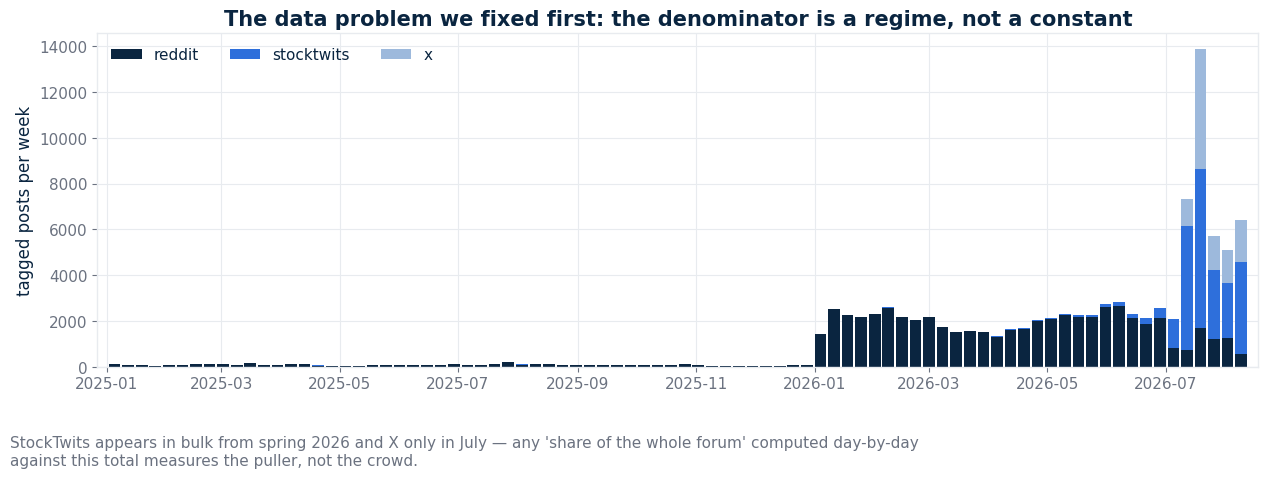

In [3]:
# S0a — the denominator is a regime, not a constant
by_src = load(TICKER_COUNTS_BY_SOURCE)
by_src["date"] = pd.to_datetime(by_src["date"])
wk = (by_src.groupby([pd.Grouper(key="date", freq="W"), "source"])
      ["mention_count"].sum().unstack(fill_value=0)).loc["2025-01-01":]
SRC_C = {"reddit": NAVY, "stocktwits": BLUE, "x": SKY}

fig, ax = plt.subplots(figsize=(12.8, 4.2))
bottom = np.zeros(len(wk))
for s in ["reddit", "stocktwits", "x"]:
    if s in wk.columns:
        ax.bar(wk.index, wk[s].values, width=6, bottom=bottom,
               color=SRC_C[s], label=s, linewidth=0)
        bottom += wk[s].values
ax.set_title("The data problem we fixed first: the denominator is a "
             "regime, not a constant", fontsize=15)
ax.set_ylabel("tagged posts per week")
ax.legend(frameon=False, ncols=3)
ax.margins(x=0.01)
fig.text(0.01, -0.06,
         "StockTwits appears in bulk from spring 2026 and X only in July — any 'share of the whole forum' computed day-by-day\n"
         "against this total measures the puller, not the crowd.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S0a_source_regime.png")
plt.show()

saved docs/figures/slides/S0b_estimator_fix.png


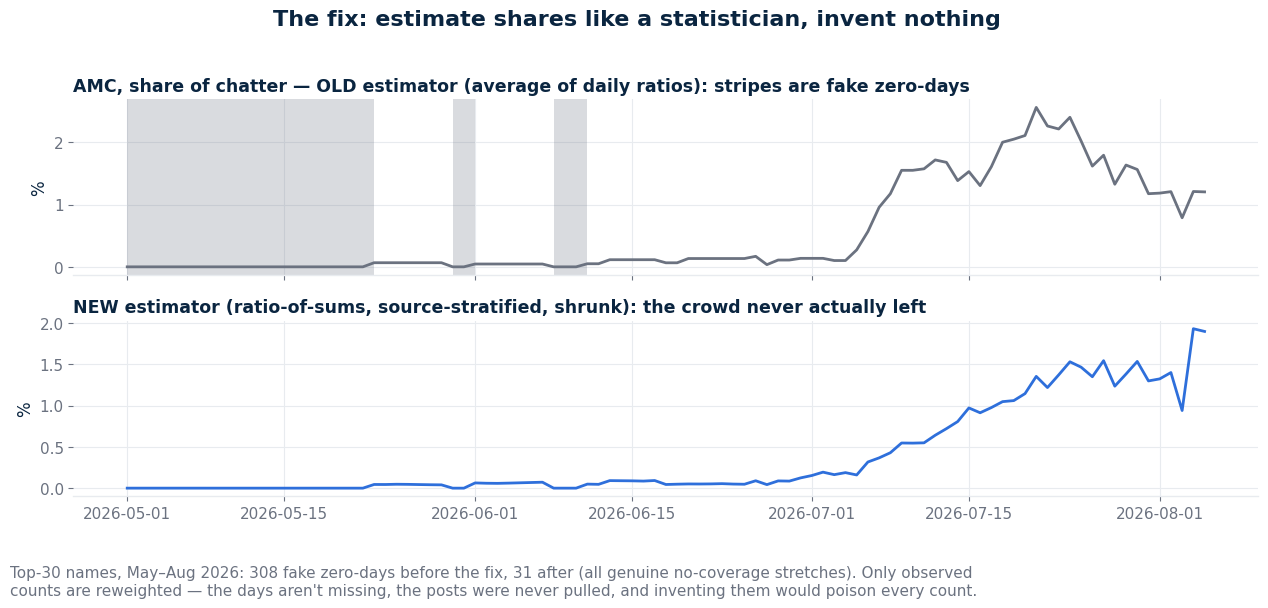

In [4]:
# S0b — the estimator fix, on the name the desk complained about
tc = counts["ticker"]
all_days = pd.date_range(tc["date"].min(), tc["date"].max(), freq="D")
day_tot = (tc.groupby("date")["mention_count"].sum()
           .reindex(all_days).fillna(0.0))
NAME0 = "AMC"
m0 = (tc[tc.ticker == NAME0].groupby("date")["mention_count"].sum()
      .reindex(all_days).fillna(0.0))
old = ((m0 / day_tot.where(day_tot > 0)) * 100).rolling(
    7, min_periods=1).mean().loc["2026-05-01":"2026-08-05"]
new = robust_share(tc, "ticker", NAME0, all_days,
                   by_source=by_src).loc["2026-05-01":"2026-08-05"]

fig, axes = plt.subplots(2, 1, figsize=(12.8, 5.2), sharex=True)
axes[0].plot(old.index, old.values, color=GREY, lw=2.0)
for d in old.index[old.fillna(0) == 0]:
    axes[0].axvspan(d, d + pd.Timedelta(days=1), color=GREY, alpha=0.25,
                    lw=0)
axes[0].set_title(f"{NAME0}, share of chatter — OLD estimator "
                  "(average of daily ratios): stripes are fake zero-days",
                  fontsize=12.5, loc="left")
axes[0].set_ylabel("%")
axes[1].plot(new.index, new.values, color=BLUE, lw=2.0)
axes[1].set_title("NEW estimator (ratio-of-sums, source-stratified, "
                  "shrunk): the crowd never actually left", fontsize=12.5,
                  loc="left")
axes[1].set_ylabel("%")
for ax in axes:
    despine(ax)
fig.suptitle("The fix: estimate shares like a statistician, invent "
             "nothing", fontsize=16, fontweight="bold", y=1.02)
fig.text(0.01, -0.05,
         "Top-30 names, May–Aug 2026: 308 fake zero-days before the fix, 31 after (all genuine no-coverage stretches). Only observed\n"
         "counts are reweighted — the days aren't missing, the posts were never pulled, and inventing them would poison every count.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S0b_estimator_fix.png")
plt.show()

---
# Q1 — What are we optimising for?

The target is the **crowd-driven boom→bust episode**: a name the retail
crowd piles into, the price runs, and then it breaks. S1a shows three
the desk names by heart; S1b shows why the definition's bars sit where
they do; S1c anatomises one episode and the exact windows a call is
graded against.

saved docs/figures/slides/S1a_what_we_hunt.png


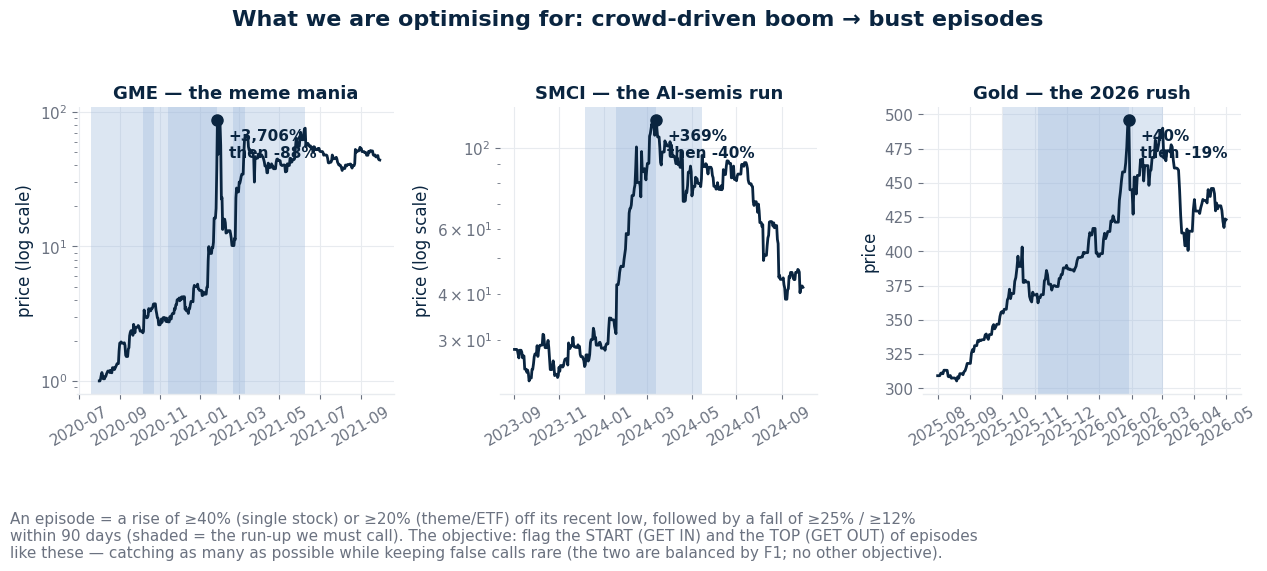

In [5]:
# S1a — the anatomy of what we hunt, on three famous cases
CASES1 = [("GME — the meme mania", "GME", "2020-08-01", "2021-09-30"),
          ("SMCI — the AI-semis run", "SMCI", "2023-09-01", "2024-09-30"),
          ("Gold — the 2026 rush", "GLD", "2025-08-01", "2026-05-01")]

fig, axes = plt.subplots(1, 3, figsize=(12.8, 4.4))
for ax, (title, sym, w0, w1) in zip(axes, CASES1):
    px = pxmap[sym].dropna().loc[w0:w1]
    ax.plot(px.index, px.values, color=NAVY, lw=2.0)
    eps_n = episodes[(episodes.symbol == sym)
                     & (episodes.peak >= w0) & (episodes.peak <= w1)]
    for r in eps_n.itertuples():
        ax.axvspan(r.trough, r.peak, color=SKY, alpha=0.35, lw=0)
    if len(eps_n):
        big = eps_n.loc[eps_n.boom_pct.idxmax()]
        pk = px.asof(big.peak)
        ax.plot([big.peak], [pk], "o", color=NAVY, ms=8, zorder=5)
        ax.annotate(f"+{big.boom_pct*100:,.0f}%\nthen "
                    f"{big.bust_pct*100:,.0f}%",
                    (big.peak, pk), xytext=(8, -6),
                    textcoords="offset points", fontsize=11,
                    fontweight="bold", color=NAVY, va="top")
    if px.max() / max(px.min(), 1e-9) > 4:
        ax.set_yscale("log")
        ax.set_ylabel("price (log scale)")
    else:
        ax.set_ylabel("price")
    ax.set_title(title, fontsize=13)
    ax.tick_params(axis="x", rotation=30)
    despine(ax)
fig.suptitle("What we are optimising for: crowd-driven boom → bust "
             "episodes", fontsize=16, fontweight="bold", y=1.04)
fig.text(0.01, -0.10,
         "An episode = a rise of ≥40% (single stock) or ≥20% (theme/ETF) off its recent low, followed by a fall of ≥25% / ≥12%\n"
         "within 90 days (shaded = the run-up we must call). The objective: flag the START (GET IN) and the TOP (GET OUT) of episodes\n"
         "like these — catching as many as possible while keeping false calls rare (the two are balanced by F1; no other objective).",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S1a_what_we_hunt.png")
plt.show()

saved docs/figures/slides/S1b_why_these_bars.png


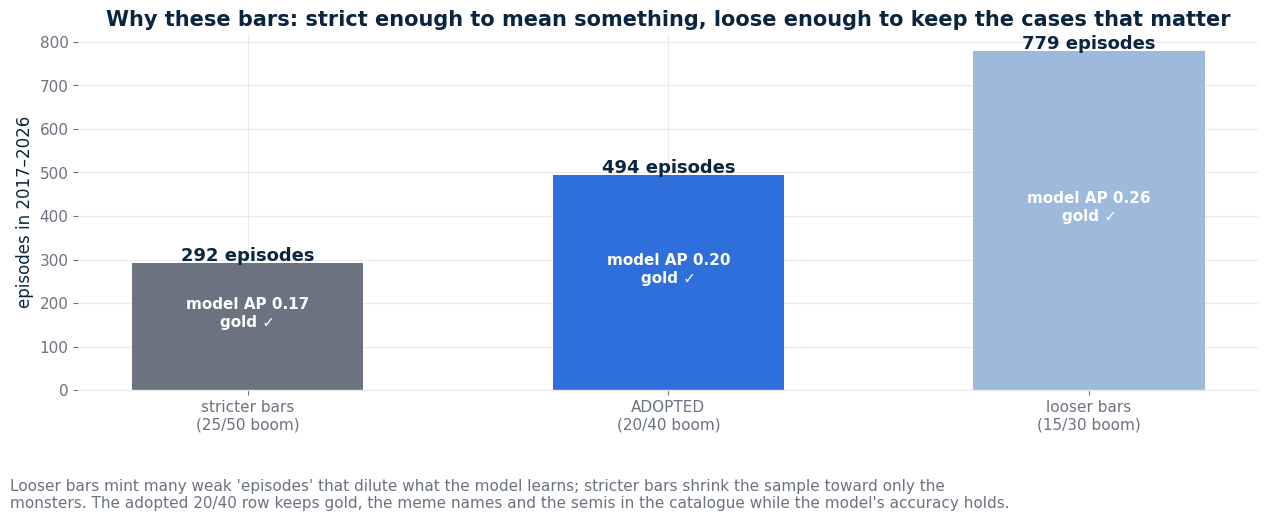

In [6]:
# S1b — why the definition's bars sit where they do (the sweep)
order = ["GT-old (25/50, 15/30)", "GT-ADOPTED (20/40, 12/25)",
         "GT-loosest (15/30, 10/20)"]
labels1 = ["stricter bars\n(25/50 boom)", "ADOPTED\n(20/40 boom)",
           "looser bars\n(15/30 boom)"]
fig, ax = plt.subplots(figsize=(12.8, 4.6))
xs = np.arange(len(order))
eps_counts = [GT_SWEEP[k]["episodes"] for k in order]
bars = ax.bar(xs, eps_counts, 0.55, color=[GREY, BLUE, SKY])
for x, b, k in zip(xs, bars, order):
    ap = GT_SWEEP[k]["get_out"]["ap"]
    gold = "gold ✓" if any("gold" in t for t in
                                GT_SWEEP[k]["themes_with_episode"]) \
        else "gold ✗"
    ax.text(x, b.get_height() + 6, f"{int(b.get_height())} episodes",
            ha="center", fontsize=13, fontweight="bold", color=NAVY)
    ax.text(x, b.get_height() / 2,
            f"model AP {ap:.2f}\n{gold}", ha="center", fontsize=11,
            color="white", fontweight="bold")
ax.set_xticks(xs, labels1)
ax.set_ylabel("episodes in 2017–2026")
ax.set_title("Why these bars: strict enough to mean something, loose "
             "enough to keep the cases that matter", fontsize=15)
fig.text(0.01, -0.06,
         "Looser bars mint many weak 'episodes' that dilute what the model learns; stricter bars shrink the sample toward only the\n"
         "monsters. The adopted 20/40 row keeps gold, the meme names and the semis in the catalogue while the model's accuracy holds.",
         fontsize=11, color=GREY, va="top")
despine(ax)
fig.tight_layout()
save(fig, "S1b_why_these_bars.png")
plt.show()

saved docs/figures/slides/S1c_episode_anatomy.png


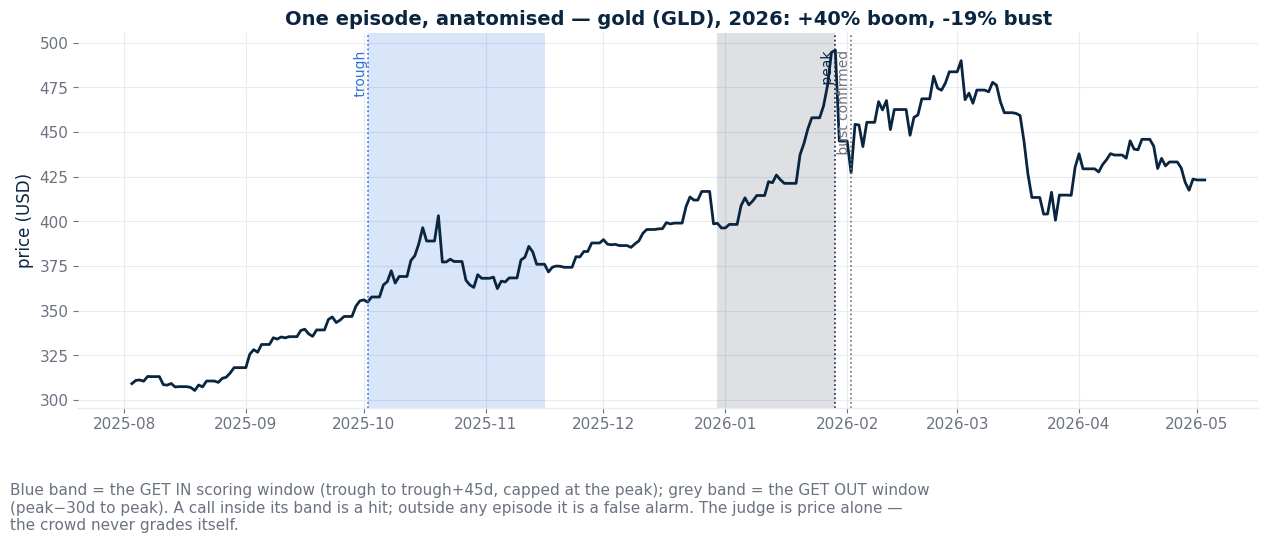

In [7]:
# S1c — one episode anatomised: the exact windows a call is graded on
EP_NAME = "gold_metals"
ep = episodes[episodes["name"] == EP_NAME].sort_values("boom_pct").iloc[-1]
px1 = pxmap[ep["symbol"]].dropna()
win = px1.loc[ep["trough"] - pd.Timedelta(days=60):
              (ep["bust_date"] if pd.notna(ep["bust_date"]) else ep["peak"])
              + pd.Timedelta(days=90)]

fig, ax = plt.subplots(figsize=(12.8, 4.6))
ax.plot(win.index, win.values, color=NAVY, lw=2.0)
ax.axvspan(ep["onset_lo"], ep["onset_hi"], color=BLUE, alpha=0.18, lw=0)
ax.axvspan(ep["peak"] - pd.Timedelta(days=30), ep["peak"], color=GREY,
           alpha=0.22, lw=0)
for d, lbl, c in ((ep["trough"], "trough", BLUE),
                  (ep["peak"], "peak", NAVY),
                  (ep["bust_date"], "bust confirmed", GREY)):
    if d is None or pd.isna(d):
        continue
    ax.axvline(d, color=c, lw=1.2, ls=":")
    ax.annotate(f" {lbl}", (d, win.max()), rotation=90, fontsize=10,
                color=c, va="top", ha="right")
ax.set_title(f"One episode, anatomised — gold ({ep['symbol']}), "
             f"{ep['peak'].year}: +{ep['boom_pct']:.0%} boom, "
             f"{ep['bust_pct']:.0%} bust", fontsize=14)
ax.set_ylabel("price (USD)")
despine(ax)
fig.text(0.01, -0.07,
         "Blue band = the GET IN scoring window (trough to trough+45d, capped at the peak); grey band = the GET OUT window\n"
         "(peak−30d to peak). A call inside its band is a hit; outside any episode it is a false alarm. The judge is price alone —\n"
         "the crowd never grades itself.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S1c_episode_anatomy.png")
plt.show()

---
# Q2 — What features come from the raw data?

Three raw streams — **how many are talking, what they are saying, and
what price is doing** — become eleven trailing measurements. S2a shows
the raw streams on the GME mania; S2b lists all eleven in plain English.

saved docs/figures/slides/S2a_three_streams.png


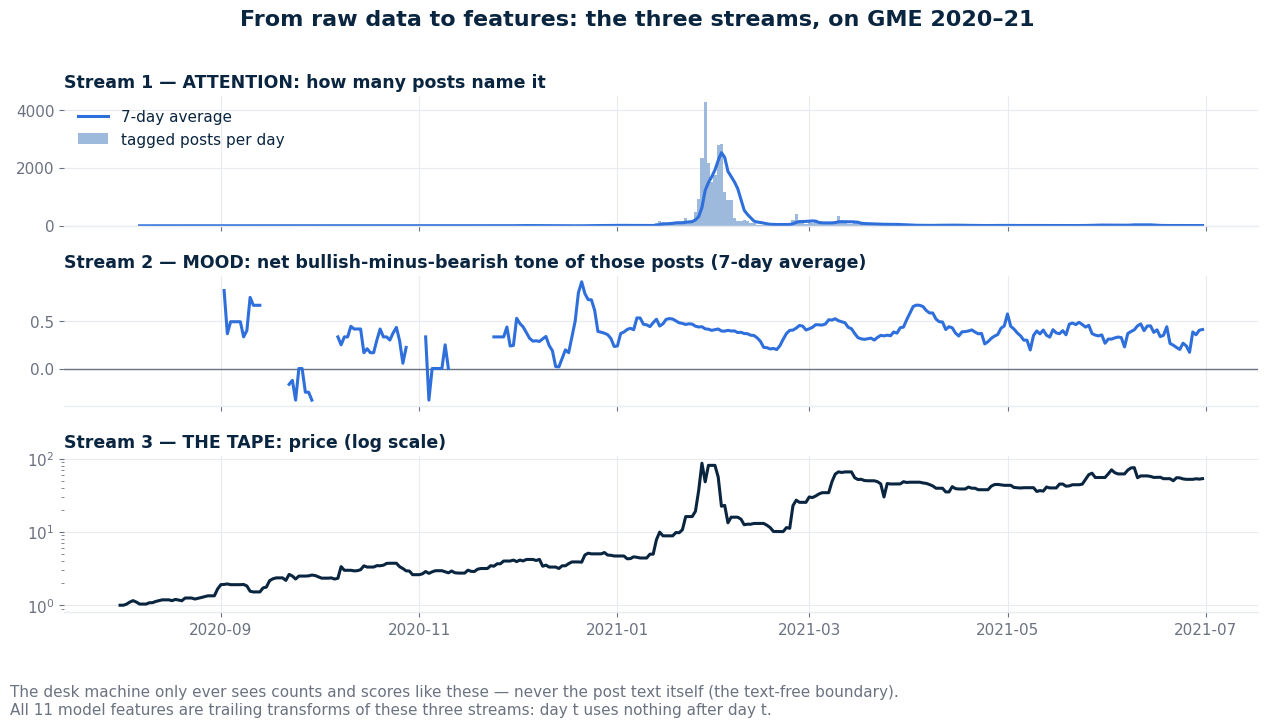

In [8]:
# S2a — the three raw streams, on the case everyone knows
name2, sym2 = "GME", "GME"
w0, w1 = "2020-08-01", "2021-06-30"
m = (counts["ticker"][counts["ticker"].ticker == name2]
     .set_index("date")["mention_count"].asfreq("D").fillna(0).loc[w0:w1])
nb = (sents["ticker"][sents["ticker"].ticker == name2]
      .set_index("date")["net_bullish"].asfreq("D").loc[w0:w1])
px2 = pxmap[sym2].dropna().loc[w0:w1]

fig, axes = plt.subplots(3, 1, figsize=(12.8, 6.4), sharex=True,
                         height_ratios=[1, 1, 1.2])
axes[0].bar(m.index, m.values, color=SKY, width=1.0,
            label="tagged posts per day")
axes[0].plot(m.rolling(7).mean(), color=BLUE, lw=2.2,
             label="7-day average")
axes[0].set_title("Stream 1 — ATTENTION: how many posts name it",
                  fontsize=12.5, loc="left")
axes[0].legend(frameon=False, loc="upper left")
axes[1].axhline(0, color=GREY, lw=1)
axes[1].plot(nb.rolling(7, min_periods=3).mean(), color=BLUE, lw=2.2)
axes[1].set_title("Stream 2 — MOOD: net bullish-minus-bearish tone of "
                  "those posts (7-day average)", fontsize=12.5, loc="left")
axes[2].plot(px2.index, px2.values, color=NAVY, lw=2.2)
axes[2].set_yscale("log")
axes[2].set_title("Stream 3 — THE TAPE: price (log scale)",
                  fontsize=12.5, loc="left")
for ax in axes:
    despine(ax)
fig.suptitle("From raw data to features: the three streams, on GME "
             "2020–21", fontsize=16, fontweight="bold", y=1.01)
fig.text(0.01, -0.045,
         "The desk machine only ever sees counts and scores like these — never the post text itself (the text-free boundary).\n"
         "All 11 model features are trailing transforms of these three streams: day t uses nothing after day t.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S2a_three_streams.png")
plt.show()

saved docs/figures/slides/S2b_the_11_measurements.png


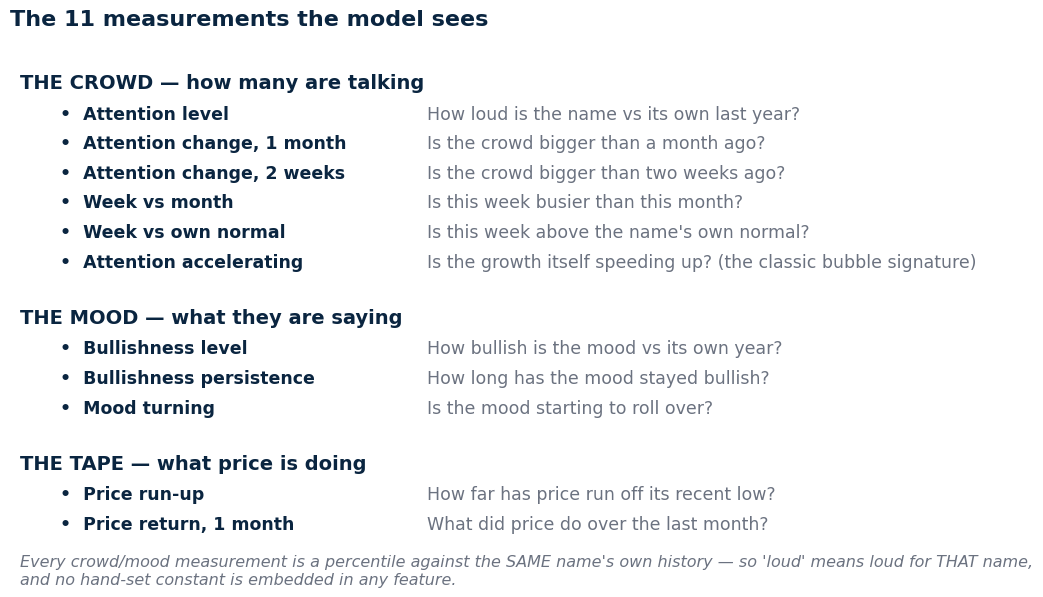

In [9]:
# S2b — the 11 measurements, in plain English
ROWS2 = [
    ("THE CROWD — how many are talking", None),
    ("Attention level", "How loud is the name vs its own last year?"),
    ("Attention change, 1 month", "Is the crowd bigger than a month ago?"),
    ("Attention change, 2 weeks", "Is the crowd bigger than two weeks ago?"),
    ("Week vs month", "Is this week busier than this month?"),
    ("Week vs own normal", "Is this week above the name's own normal?"),
    ("Attention accelerating", "Is the growth itself speeding up? "
                               "(the classic bubble signature)"),
    ("THE MOOD — what they are saying", None),
    ("Bullishness level", "How bullish is the mood vs its own year?"),
    ("Bullishness persistence", "How long has the mood stayed bullish?"),
    ("Mood turning", "Is the mood starting to roll over?"),
    ("THE TAPE — what price is doing", None),
    ("Price run-up", "How far has price run off its recent low?"),
    ("Price return, 1 month", "What did price do over the last month?"),
]
fig, ax = plt.subplots(figsize=(12.8, 6.2))
ax.axis("off")
y = 1.0
for label, q in ROWS2:
    if q is None:
        y -= 0.055
        ax.text(0.01, y, label, fontsize=14, fontweight="bold",
                color=NAVY, va="top")
        y -= 0.065
    else:
        ax.text(0.05, y, f"•  {label}", fontsize=12.5, color=NAVY,
                va="top", fontweight="bold")
        ax.text(0.42, y, q, fontsize=12.5, color=GREY, va="top")
        y -= 0.062
ax.text(0.01, y - 0.02,
        "Every crowd/mood measurement is a percentile against the SAME "
        "name's own history — so 'loud' means loud for THAT name,\nand no "
        "hand-set constant is embedded in any feature.",
        fontsize=11.5, color=GREY, va="top", style="italic")
ax.set_title("The 11 measurements the model sees", fontsize=16,
             loc="left", pad=16)
save(fig, "S2b_the_11_measurements.png")
plt.show()

---
# Q3 — What choices did we have?

saved docs/figures/slides/S3_the_menu.png


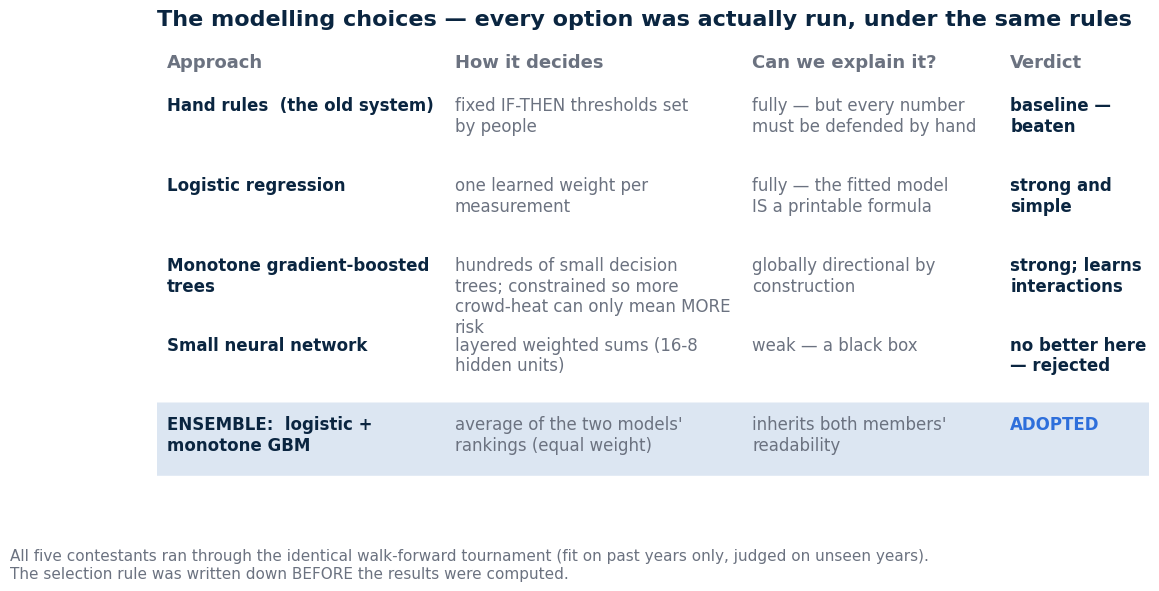

In [10]:
# S3 — the menu of approaches, and the verdict on each
import textwrap
MENU = [
    ("Hand rules  (the old system)",
     "fixed IF-THEN thresholds set by people",
     "fully — but every number must be defended by hand",
     "baseline — beaten"),
    ("Logistic regression",
     "one learned weight per measurement",
     "fully — the fitted model IS a printable formula",
     "strong and simple"),
    ("Monotone gradient-boosted trees",
     "hundreds of small decision trees; constrained so more crowd-heat "
     "can only mean MORE risk",
     "globally directional by construction",
     "strong; learns interactions"),
    ("Small neural network",
     "layered weighted sums (16-8 hidden units)",
     "weak — a black box",
     "no better here — rejected"),
    ("ENSEMBLE:  logistic + monotone GBM",
     "average of the two models' rankings (equal weight)",
     "inherits both members' readability",
     "ADOPTED"),
]
fig, ax = plt.subplots(figsize=(12.8, 5.6))
ax.axis("off")
cols_x = [0.01, 0.30, 0.60, 0.86]
for cx, h in zip(cols_x, ["Approach", "How it decides",
                          "Can we explain it?", "Verdict"]):
    ax.text(cx, 0.98, h, fontsize=13, fontweight="bold", color=GREY,
            va="top")
y = 0.88
for row in MENU:
    if row[3] == "ADOPTED":
        ax.add_patch(mpatches.FancyBboxPatch(
            (-0.005, y - 0.135), 1.005, 0.16,
            boxstyle="round,pad=0.005", facecolor=SKY, alpha=0.35,
            edgecolor="none", transform=ax.transAxes))
    for cx, txt, w in zip(cols_x, row, [0.27, 0.28, 0.24, 0.14]):
        fw = "bold" if cx in (cols_x[0], cols_x[3]) else "normal"
        c = BLUE if (row[3] == "ADOPTED" and cx == cols_x[3]) else \
            (NAVY if fw == "bold" else GREY)
        ax.text(cx, y, "\n".join(textwrap.wrap(txt, int(w * 105))),
                fontsize=12, fontweight=fw, color=c, va="top")
    y -= 0.185
ax.set_title("The modelling choices — every option was actually run, "
             "under the same rules", fontsize=16, loc="left", pad=14)
fig.text(0.01, -0.02,
         "All five contestants ran through the identical walk-forward tournament (fit on past years only, judged on unseen years).\n"
         "The selection rule was written down BEFORE the results were computed.",
         fontsize=11, color=GREY, va="top")
save(fig, "S3_the_menu.png")
plt.show()

---
# Q4 — Which features were good?

Two independent reads. **S4a**: each measurement ALONE as a detector —
AUROC, where 0.50 is a coin flip. **S4b**: remove one measurement from
the adopted model and measure the accuracy (AP) it loses — the
ablation. A feature can look modest alone but matter in combination
(and vice versa), which is why both views are shown.

saved docs/figures/slides/S4a_feature_auroc.png


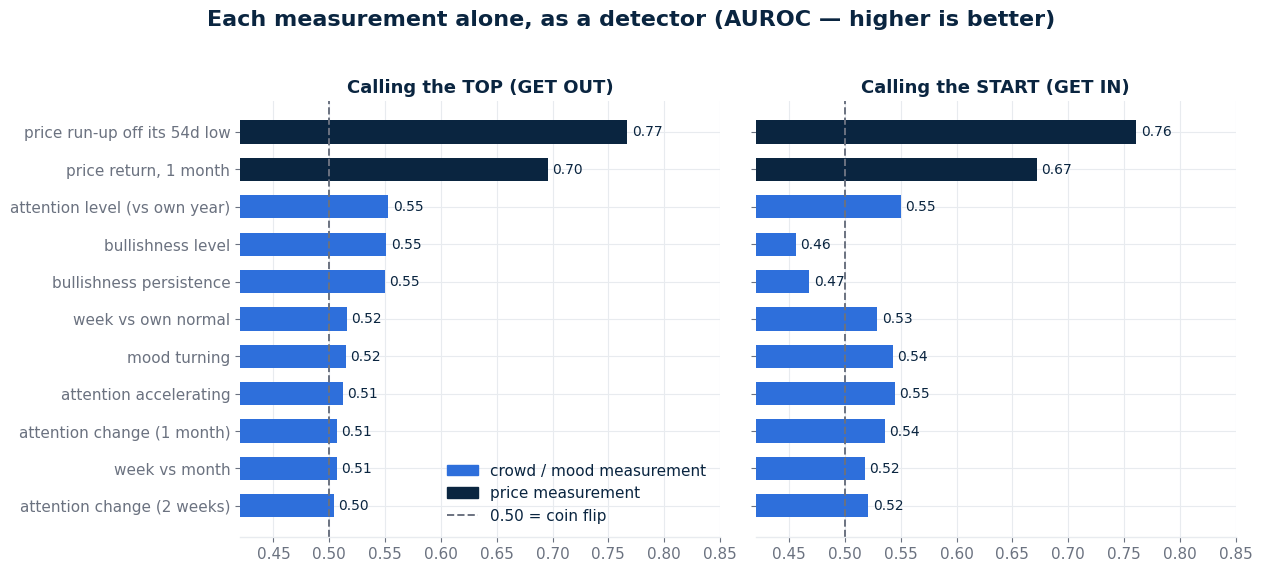

In [11]:
# S4a — every measurement alone (single-feature AUROC, walk-forward)
bb = pd.DataFrame(BANK_BOARD)
fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.6), sharey=True)
for ax, col, ttl in ((axes[0], "AUROC vs y_top",
                      "Calling the TOP (GET OUT)"),
                     (axes[1], "AUROC vs y_onset",
                      "Calling the START (GET IN)")):
    d = bb.sort_values("AUROC vs y_top")
    cs = [NAVY if c in ("price_runup", "price_ret21") else BLUE
          for c in d["column"]]
    ax.barh(d["feature"], d[col], color=cs, height=0.62)
    ax.axvline(0.5, color=GREY, lw=1.4, ls="--")
    for i, v in enumerate(d[col]):
        ax.text(v + 0.004, i, f"{v:.2f}", va="center", fontsize=10,
                color=NAVY)
    ax.set_xlim(0.42, 0.85)
    ax.set_title(ttl, fontsize=13)
    despine(ax, keep_bottom=True)
axes[0].legend(handles=[mpatches.Patch(color=BLUE, label="crowd / mood "
                                       "measurement"),
                        mpatches.Patch(color=NAVY,
                                       label="price measurement"),
                        Line2D([0], [0], color=GREY, lw=1.4, ls="--",
                               label="0.50 = coin flip")],
               frameon=False, loc="lower right")
fig.suptitle("Each measurement alone, as a detector (AUROC — higher is "
             "better)", fontsize=16, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "S4a_feature_auroc.png")
plt.show()

GET OUT: full-model AP 0.379 | ablation 8s


GET IN: full-model AP 0.346 | ablation 7s


saved docs/figures/slides/S4b_ablation.png


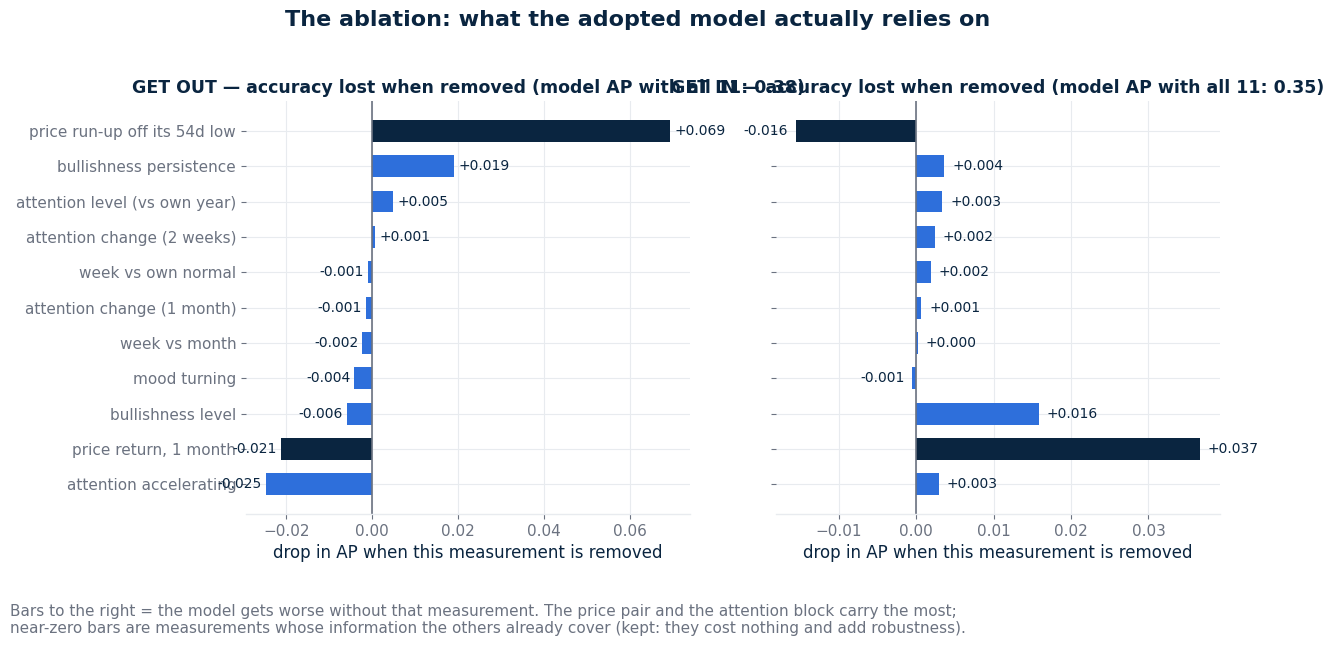

In [12]:
# S4b — the ablation: drop one measurement, refit the adopted model,
# measure the accuracy lost (final fold: fit < newest year, test on it)
ymax = int(cand_px["year"].max())
tr_f = cand_px[cand_px["year"] < ymax]
te_f = cand_px[cand_px["year"] == ymax]
PLAIN = {r["column"]: r["feature"] for r in BANK_BOARD}


def fold_ap(label, feats):
    sc = mld.make_ens_fit(label)(tr_f, te_f, feats)
    return average_precision_score(te_f[label], sc)


abl = {}
for label, head in (("y_top", "GET OUT"), ("y_onset", "GET IN")):
    t1 = time.time()
    full = fold_ap(label, mld.DESK_ML_BANK)
    rows = []
    for f0 in mld.DESK_ML_BANK:
        rest = [f for f in mld.DESK_ML_BANK if f != f0]
        rows.append({"column": f0, "feature": PLAIN.get(f0, f0),
                     "delta": full - fold_ap(label, rest)})
    abl[head] = (full, pd.DataFrame(rows))
    print(f"{head}: full-model AP {full:.3f} | ablation "
          f"{time.time()-t1:.0f}s")

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.6), sharey=True)
sort_order = abl["GET OUT"][1].sort_values("delta")["feature"]
for ax, head in ((axes[0], "GET OUT"), (axes[1], "GET IN")):
    full, d = abl[head]
    d = d.set_index("feature").loc[sort_order].reset_index()
    cs = [NAVY if c in ("price_runup", "price_ret21") else BLUE
          for c in d["column"]]
    ax.barh(d["feature"], d["delta"], color=cs, height=0.62)
    ax.axvline(0, color=GREY, lw=1.2)
    for i, v in enumerate(d["delta"]):
        ax.text(v + (0.001 if v >= 0 else -0.001), i, f"{v:+.3f}",
                va="center", ha="left" if v >= 0 else "right",
                fontsize=10, color=NAVY)
    ax.set_title(f"{head} — accuracy lost when removed "
                 f"(model AP with all 11: {full:.2f})", fontsize=12.5)
    ax.set_xlabel("drop in AP when this measurement is removed")
    despine(ax)
fig.suptitle("The ablation: what the adopted model actually relies on",
             fontsize=16, fontweight="bold", y=1.02)
fig.text(0.01, -0.04,
         "Bars to the right = the model gets worse without that measurement. The price pair and the attention block carry the most;\n"
         "near-zero bars are measurements whose information the others already cover (kept: they cost nothing and add robustness).",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S4b_ablation.png")
plt.show()

---
# Q5 — Why this particular model?

saved docs/figures/slides/S5_why_this_model.png


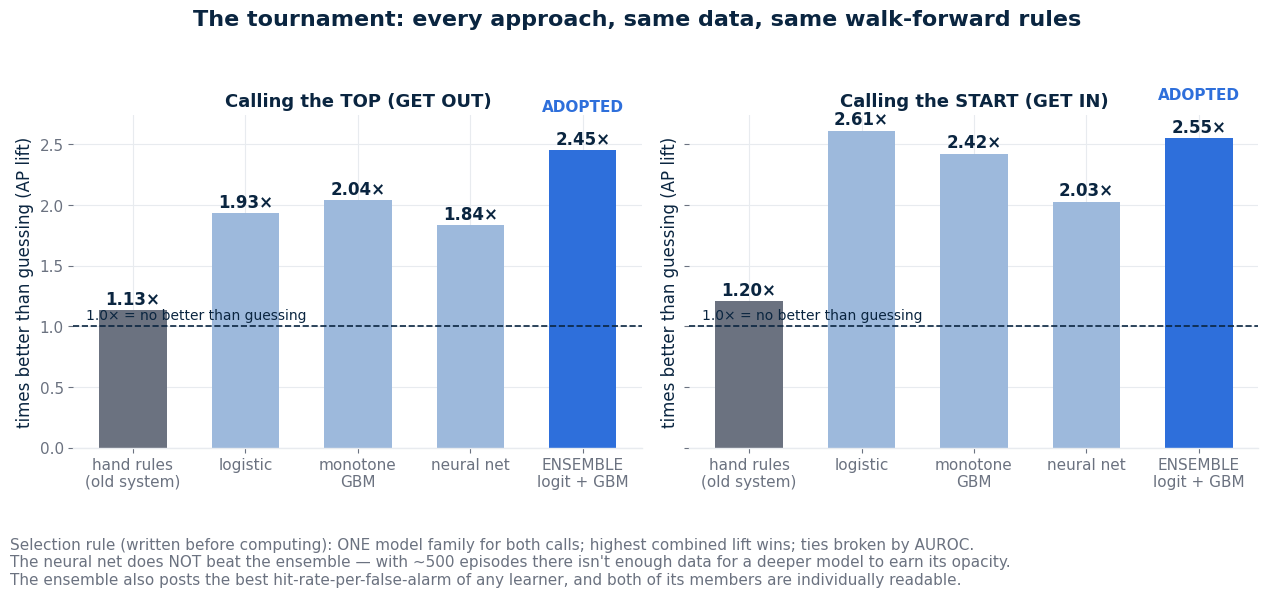

In [13]:
# S5 — the tournament, one bar per contestant (AP lift: how many times
# better than guessing, each on its own candidate frame)
MODELS = [("rules", "hand rules\n(old system)"), ("logit", "logistic"),
          ("gbm", "monotone\nGBM"), ("mlp", "neural net"),
          ("ens", "ENSEMBLE\nlogit + GBM")]
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), sharey=True)
for ax, head, ttl in ((axes[0], "get_out", "Calling the TOP (GET OUT)"),
                      (axes[1], "get_in", "Calling the START (GET IN)")):
    lifts = [RES[head][m]["ap"] / RES[head][m]["ap_baseline"]
             for m, _ in MODELS]
    cs = [GREY if m == "rules" else (BLUE if m == "ens" else SKY)
          for m, _ in MODELS]
    bars = ax.bar(range(len(MODELS)), lifts, 0.6, color=cs)
    ax.axhline(1.0, color=NAVY, lw=1.2, ls="--")
    ax.text(-0.42, 1.06, "1.0× = no better than guessing",
            fontsize=10, color=NAVY)
    for i, v in enumerate(lifts):
        ax.text(i, v + 0.05, f"{v:.2f}×", ha="center", fontsize=12,
                fontweight="bold", color=NAVY)
    wi = [m for m, _ in MODELS].index("ens")
    ax.text(wi, lifts[wi] + 0.32, "ADOPTED", ha="center", fontsize=11,
            fontweight="bold", color=BLUE)
    ax.set_xticks(range(len(MODELS)), [l for _, l in MODELS], fontsize=11)
    ax.set_title(ttl, fontsize=13)
    ax.set_ylabel("times better than guessing (AP lift)")
    despine(ax)
fig.suptitle("The tournament: every approach, same data, same "
             "walk-forward rules", fontsize=16, fontweight="bold", y=1.04)
fig.text(0.01, -0.06,
         "Selection rule (written before computing): ONE model family for both calls; highest combined lift wins; ties broken by AUROC.\n"
         "The neural net does NOT beat the ensemble — with ~500 episodes there isn't enough data for a deeper model to earn its opacity.\n"
         "The ensemble also posts the best hit-rate-per-false-alarm of any learner, and both of its members are individually readable.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S5_why_this_model.png")
plt.show()

**IF ASKED — "why does the old system's raw precision look high?"**
Its gates pre-filter the candidate frame to days where ~half are
already inside an episode window (base rate ~0.48 vs 0.10 open). Raw
AP rewards the doorman, not the judge; lift is the comparable number,
and on lift the old rules are 1.1–1.2× — barely above chance.

**Deep-dive pointers:** notebook 03 §SS2.0 executes the full training
recipe step by step (the printed logit formula, the rank-average
arithmetic, the F1 curve the cut is read from); 03 §SS1 is the formal
head-to-head vs the previous rules; 04 §SS.1 is the plain-language
report card.

---
# Q6 — Why these thresholds? (and the final feature set)

The walk-forward member scores are computed once here (cached to
`docs/research/nb07_wf_scores.parquet`) and reused for §6.5's
conditioning study and §7's worked examples — the SAME construction
production uses: fit on years < Y, score year Y, rank-average the two
members within the year.

In [14]:
CACHE = RESEARCH_DIR / "nb07_wf_scores.parquet"
FP = {"rows": len(cand_px), "max_date": str(cand_px["date"].max().date())}
WF = None
if CACHE.exists():
    _c = pd.read_parquet(CACHE)
    if ("fingerprint" in _c.columns
            and json.loads(_c["fingerprint"].iloc[0]) == FP):
        WF = _c.drop(columns=["fingerprint"])
        print("reusing cached walk-forward scores")
if WF is None:
    parts = []
    for label, head in (("y_top", "GET OUT"), ("y_onset", "GET IN")):
        t1 = time.time()
        key = ["name", "date", "test_year"]
        lg = walk_forward_scores(cand_px, mld.DESK_ML_BANK, label,
                                 mld.make_logit_fit(label))
        gb = walk_forward_scores(cand_px, mld.DESK_ML_BANK, label,
                                 mld.make_gbm_fit(label))
        m = (lg[key + [label, "score"]].rename(columns={"score": "logit"})
             .merge(gb[key + ["score"]].rename(columns={"score": "gbm"}),
                    on=key))
        m["logit_rank"] = m.groupby("test_year")["logit"].rank(pct=True)
        m["gbm_rank"] = m.groupby("test_year")["gbm"].rank(pct=True)
        m["score"] = (m["logit_rank"] + m["gbm_rank"]) / 2
        m["head"] = head
        m = m.rename(columns={label: "y"})
        parts.append(m)
        print(f"{head}: walk-forward members {time.time()-t1:.0f}s")
    WF = pd.concat(parts, ignore_index=True)
    out = WF.copy()
    out["fingerprint"] = json.dumps(FP)
    out.to_parquet(CACHE, index=False)
    print(f"cached -> {CACHE.relative_to(ROOT)}")

THR = {h: {int(k): v for k, v in RES[hk]["ens"]["thresholds"].items()}
       for h, hk in (("GET OUT", "get_out"), ("GET IN", "get_in"))}

reusing cached walk-forward scores


saved docs/figures/slides/S6a_score_distributions.png


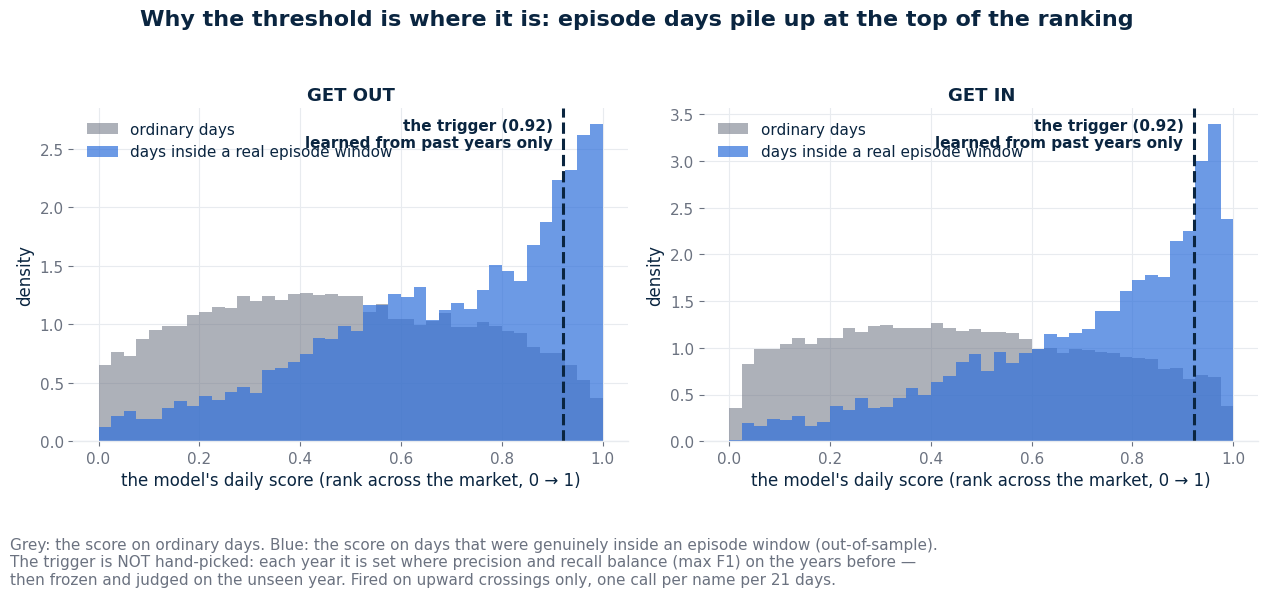

In [15]:
# S6a — where the trigger sits: the two score distributions and the cut
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))
for ax, head in ((axes[0], "GET OUT"), (axes[1], "GET IN")):
    d = WF[WF["head"] == head]
    bins = np.linspace(0, 1, 41)
    ax.hist(d.loc[d.y == 0, "score"], bins=bins, density=True,
            color=GREY, alpha=0.55, label="ordinary days")
    ax.hist(d.loc[d.y == 1, "score"], bins=bins, density=True,
            color=BLUE, alpha=0.70, label="days inside a real episode "
            "window")
    thr = THR[head][max(THR[head])]
    ax.axvline(thr, color=NAVY, lw=2.2, ls="--")
    ax.text(thr - 0.02, ax.get_ylim()[1] * 0.97,
            f"the trigger ({thr:.2f})\nlearned from past years only",
            ha="right", va="top", fontsize=11, fontweight="bold",
            color=NAVY)
    ax.set_title(head, fontsize=13)
    ax.set_xlabel("the model's daily score (rank across the market, "
                  "0 → 1)")
    ax.set_ylabel("density")
    ax.legend(frameon=False, loc="upper left")
    despine(ax)
fig.suptitle("Why the threshold is where it is: episode days pile up at "
             "the top of the ranking", fontsize=16, fontweight="bold",
             y=1.04)
fig.text(0.01, -0.06,
         "Grey: the score on ordinary days. Blue: the score on days that were genuinely inside an episode window (out-of-sample).\n"
         "The trigger is NOT hand-picked: each year it is set where precision and recall balance (max F1) on the years before —\n"
         "then frozen and judged on the unseen year. Fired on upward crossings only, one call per name per 21 days.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S6a_score_distributions.png")
plt.show()

saved docs/figures/slides/S6b_spearman_and_cuts.png


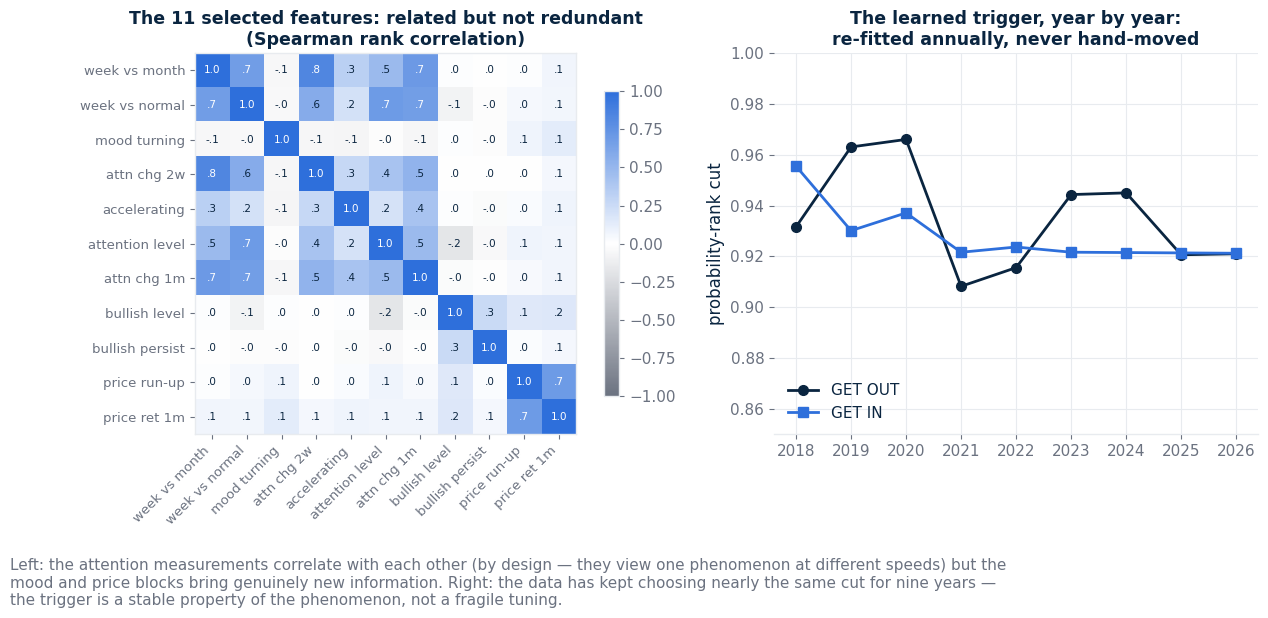

In [16]:
# S6b — the final feature set holds together (Spearman) + the learned
# cut has been stable year after year
plain_short = {
    "e1": "attention level", "e3": "attn chg 1m",
    "influx_speed": "attn chg 2w", "attention_accel": "week vs month",
    "hype_ratio": "week vs normal", "attention_convexity": "accelerating",
    "bull_level": "bullish level", "bull_persist": "bullish persist",
    "bull_inflection": "mood turning", "price_runup": "price run-up",
    "price_ret21": "price ret 1m"}
corr = cand_px[mld.DESK_ML_BANK].corr(method="spearman")
cmap = LinearSegmentedColormap.from_list("bg", [GREY, "#FFFFFF", BLUE])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 5.4),
                               width_ratios=[1.15, 1])
im = ax1.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1)
ax1.set_xticks(range(len(corr)),
               [plain_short[c] for c in corr.columns], rotation=45,
               ha="right", fontsize=9.5)
ax1.set_yticks(range(len(corr)),
               [plain_short[c] for c in corr.columns], fontsize=9.5)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.values[i, j]
        ax1.text(j, i, f"{v:.1f}".replace("0.", "."), ha="center",
                 va="center", fontsize=7.5,
                 color="white" if abs(v) > 0.6 else NAVY)
ax1.set_title("The 11 selected features: related but not redundant\n"
              "(Spearman rank correlation)", fontsize=12.5)
ax1.grid(False)
fig.colorbar(im, ax=ax1, shrink=0.8)

for head, c, mk in (("GET OUT", NAVY, "o"), ("GET IN", BLUE, "s")):
    yrs = sorted(THR[head])
    ax2.plot(yrs, [THR[head][y] for y in yrs], color=c, lw=2.0,
             marker=mk, ms=7, label=head)
ax2.set_ylim(0.85, 1.0)
ax2.set_title("The learned trigger, year by year:\nre-fitted annually, "
              "never hand-moved", fontsize=12.5)
ax2.set_ylabel("probability-rank cut")
ax2.legend(frameon=False, loc="lower left")
despine(ax2)
fig.text(0.01, -0.05,
         "Left: the attention measurements correlate with each other (by design — they view one phenomenon at different speeds) but the\n"
         "mood and price blocks bring genuinely new information. Right: the data has kept choosing nearly the same cut for nine years —\n"
         "the trigger is a stable property of the phenomenon, not a fragile tuning.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S6b_spearman_and_cuts.png")
plt.show()

---
# Q6.5 — One clear call per boom: the alert shape (desk orders 2026-08-09)

**The complaints, verbatim:** GET OUT calls "all the way up a price
graph"; "we CANNOT have a get in and a get out so close together";
"I don't want many many get ins — a clear GET IN at the start of the
boom and a GET OUT quite near the top."

**Two rounds of evidence, both frozen.** Round 1
(`conditioning_sweep.json`) tested score smoothing (the desk's own
suggestion — REJECTED: it cost 10 points of GET OUT capture), a
stricter cut, and a crossing trigger. Round 2
(`alert_shape_sweep.json`) found the deeper cause: the two heads'
scores are near-twins, so they cross together — no trigger tweak can
fix that. The adopted design makes the heads STRUCTURALLY disjoint by
reusing the episode definition itself as a phase gate:

* **GET OUT may only fire after the boom** — price ≥ the ground
  truth's own 120d boom bar (20% themes / 40% singles). Re-arms at
  the cut.
* **GET IN may only fire before the boom completes.** Re-arms only
  when the crowd fully cools (the train-median score).
* **One call per name per quarter per side** (63d spacing), and **no
  GET IN stands within 21 days of a GET OUT, either direction** (GET
  OUT, the risk signal, is never suppressed).

No new constants: the bar, the window, the median and the 21d
separation are all reused quantities; 63d = three cooldowns.

In [17]:
_sh_rows = []
for _k, _r in SHAPE["results"].items():
    for _head in ("GET IN", "GET OUT"):
        _h = _r[_head]
        _sh_rows.append({
            "config": _k, "head": _head,
            "caught": f"{_h['captured']}/{_h['detectable']}",
            "FA": _h["false_alarms"],
            "precision": _h["precision"],
            "calls per boom": _h["calls_per_alerted_episode"],
            "alerts": _h["n_alerts"]})
display(pd.DataFrame(_sh_rows).set_index(["config", "head"]).head(24))

AD = SHAPE["adopted"]
print("ADOPTED (walk-forward record of what now ships):")
for _lbl in ("standard", "strict"):
    for _head in ("GET IN", "GET OUT"):
        _r = AD[_lbl][_head]
        print(f"  {_lbl:8s} {_head:8s} caught {_r['captured']}/"
              f"{_r['detectable']} ({_r['capture_rate']:.0%}) | "
              f"FA {_r['false_alarms']} ({_r['fa_per_iy']}/instr-yr) | "
              f"precision {_r['precision']:.0%} | alerts "
              f"{_r['n_alerts']} | median lead {_r['median_lead_days']}d")
print("Config:", json.dumps(AD["config"], indent=1))

caught  FA  precision  \
config                                      head                             
F1.0|IN=pre-boom|rearm=p*|space=21d         GET IN   22/198  55      0.286   
                                            GET OUT  75/218  65      0.536   
F1.0|IN=pre-boom|rearm=p*|space=63d         GET IN   21/198  51      0.292   
                                            GET OUT  63/218  55      0.534   
F1.0|IN=pre-boom|rearm=p*-10|space=21d      GET IN   25/198  53      0.321   
                                            GET OUT  63/218  53      0.543   
F1.0|IN=pre-boom|rearm=p*-10|space=63d      GET IN   24/198  50      0.324   
                                            GET OUT  55/218  49      0.529   
F1.0|IN=pre-boom|rearm=p50|space=21d        GET IN   25/198  50      0.333   
                                            GET OUT  56/218  42      0.571   
F1.0|IN=pre-boom|rearm=p50|space=63d        GET IN   24/198  49      0.329   
                                            GET OUT  55/218  41      0.573   
F1.0|IN=not-end-stage|rearm=p*|space=21d    GET IN   48/198  73      0.397   
                                            GET OUT  75/218  65      0.536   
F1.0|IN=not-end-stage|rearm=p*|space=63d    GET IN   43/198  63      0.406   
                                            GET OUT  63/218  55      0.534   
F1.0|IN=not-end-stage|rearm=p*-10|space=21d GET IN   49/198  70      0.412   
                                            GET OUT  63/218  53      0.543   
F1.0|IN=not-end-stage|rearm=p*-10|space=63d GET IN   44/198  63      0.411   
                                            GET OUT  55/218  49      0.529   
F1.0|IN=not-end-stage|rearm=p50|space=21d   GET IN   47/198  64      0.423   
                                            GET OUT  56/218  42      0.571   
F1.0|IN=not-end-stage|rearm=p50|space=63d   GET IN   43/198  61      0.413   
                                            GET OUT  55/218  41      0.573   

                                                     calls per boom  alerts  
config                                      head                             
F1.0|IN=pre-boom|rearm=p*|space=21d         GET IN             1.17      79  
                                            GET OUT            1.53     163  
F1.0|IN=pre-boom|rearm=p*|space=63d         GET IN             1.09      73  
                                            GET OUT            1.20     130  
F1.0|IN=pre-boom|rearm=p*-10|space=21d      GET IN             1.13      80  
                                            GET OUT            1.35     132  
F1.0|IN=pre-boom|rearm=p*-10|space=63d      GET IN             1.08      75  
                                            GET OUT            1.19     116  
F1.0|IN=pre-boom|rearm=p50|space=21d        GET IN             1.10      77  
                                            GET OUT            1.17     110  
F1.0|IN=pre-boom|rearm=p50|space=63d        GET IN             1.08      74  
                                            GET OUT            1.15     107  
F1.0|IN=not-end-stage|rearm=p*|space=21d    GET IN             1.31     142  
                                            GET OUT            1.53     163  
F1.0|IN=not-end-stage|rearm=p*|space=63d    GET IN             1.10     119  
                                            GET OUT            1.20     130  
F1.0|IN=not-end-stage|rearm=p*-10|space=21d GET IN             1.24     138  
                                            GET OUT            1.35     132  
F1.0|IN=not-end-stage|rearm=p*-10|space=63d GET IN             1.12     122  
                                            GET OUT            1.19     116  
F1.0|IN=not-end-stage|rearm=p50|space=21d   GET IN             1.16     125  
                                            GET OUT            1.17     110  
F1.0|IN=not-end-stage|rearm=p50|space=63d   GET IN             1.09     116  
                                            GET OUT            1.15     10

ADOPTED (walk-forward record of what now ships):
  standard GET IN   caught 21/198 (11%) | FA 49 (0.103/instr-yr) | precision 30% | alerts 71 | median lead 21d
  standard GET OUT  caught 63/218 (29%) | FA 55 (0.115/instr-yr) | precision 53% | alerts 130 | median lead 6d
  strict   GET IN   caught 10/198 (5%) | FA 17 (0.036/instr-yr) | precision 37% | alerts 29 | median lead 18d
  strict   GET OUT  caught 50/218 (23%) | FA 43 (0.09/instr-yr) | precision 54% | alerts 98 | median lead 7d
Config: {
 "GET IN": "pre-boom gate (run-up vs 120d low below the G2 bar), crossing, re-arm at train-median score, one call per name per 63d",
 "GET OUT": "boom gate (run-up >= G2 bar), crossing, re-arm at the cut, one call per name per 63d",
 "separation": "no GET IN stands within 21d of any GET OUT (either direction); GET OUT never suppressed"
}


saved docs/figures/slides/S6c_flip_flop_fix.png


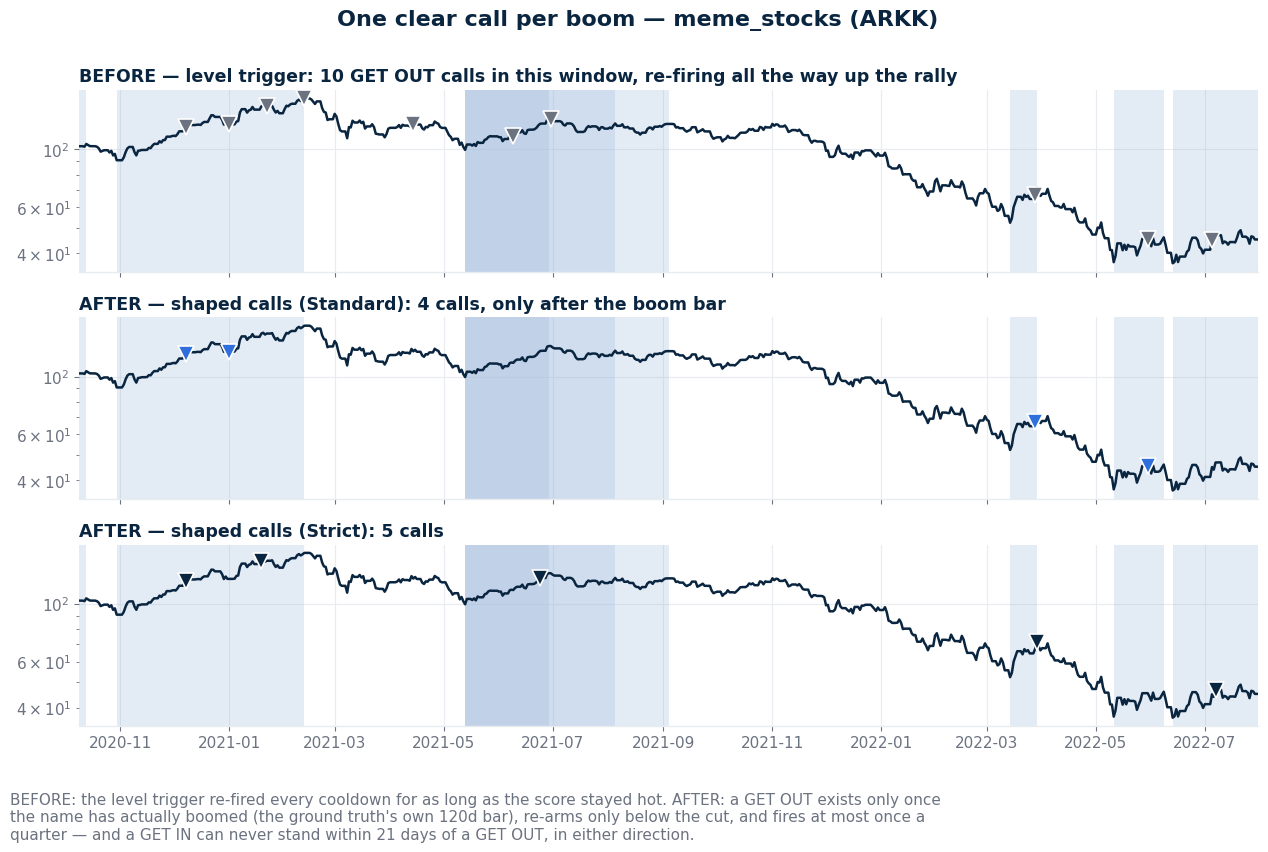

In [18]:
# S6c — before / after, on the name with the worst repeated-fire problem
def _level_alerts(head, name):
    """The ORIGINAL level trigger (the 'before' picture)."""
    d = WF[(WF["head"] == head) & (WF["name"] == name)]
    out = []
    for y, g in d.groupby("test_year"):
        thr = THR[head].get(int(y))
        if thr is None:
            continue
        g = g.sort_values("date")
        al = _alerts_int(_day_ints(g["date"]),
                         g["score"].to_numpy(float), thr)
        out += list(np.asarray(al, dtype="datetime64[D]"))
    return pd.DatetimeIndex(out)


def _adopted_alerts(head, name, setting="standard"):
    """The SHIPPED alert set (frozen in alert_shape_sweep.json)."""
    a = SHAPE["adopted"][setting]["alerts"].get(name, {})
    key = "in" if head == "GET IN" else "out"
    return pd.DatetimeIndex([pd.Timestamp(x) for x in a.get(key, [])])


_worst = max(WF["name"].unique(),
             key=lambda n: len(_level_alerts("GET OUT", n)))
_sym_w = sym_by[_worst]
_pxw = pxmap[_sym_w].dropna()
_a_old = _level_alerts("GET OUT", _worst)
_a_new = _adopted_alerts("GET OUT", _worst, "standard")
_a_str = _adopted_alerts("GET OUT", _worst, "strict")
_w0 = max(_a_old, key=lambda a: sum(
    1 for b in _a_old if a <= b <= a + pd.Timedelta(days=540)))
_w1 = _w0 + pd.Timedelta(days=540 + 60)
_w0 = _w0 - pd.Timedelta(days=60)
_pxw = _pxw.loc[_w0:_w1]

fig, axes = plt.subplots(3, 1, figsize=(12.8, 7.6), sharex=True)


def _inwin(al):
    return [a for a in al if _pxw.index.min() <= a <= _pxw.index.max()]


for ax, al, ttl, c in (
        (axes[0], _a_old, f"BEFORE — level trigger: {len(_inwin(_a_old))}"
         " GET OUT calls in this window, re-firing all the way up the "
         "rally", GREY),
        (axes[1], _a_new, f"AFTER — shaped calls (Standard): "
         f"{len(_inwin(_a_new))} calls, only after the boom bar", BLUE),
        (axes[2], _a_str, f"AFTER — shaped calls (Strict): "
         f"{len(_inwin(_a_str))} calls", NAVY)):
    ax.plot(_pxw.index, _pxw.values, color=NAVY, lw=1.8)
    if _pxw.max() / max(_pxw.min(), 1e-9) > 4:
        ax.set_yscale("log")
    for r in episodes[(episodes.name == _worst)].itertuples():
        if r.peak >= _pxw.index.min() and r.trough <= _pxw.index.max():
            ax.axvspan(max(r.trough, _pxw.index.min()),
                       min(r.peak, _pxw.index.max()), color=SKY,
                       alpha=0.28, lw=0)
    _al_w = _inwin(al)
    ax.plot(_al_w, [_pxw.asof(a) for a in _al_w], "v", color=c, ms=12,
            mec="white", mew=1.2, zorder=5)
    ax.set_xlim(_pxw.index.min(), _pxw.index.max())
    ax.set_title(ttl, fontsize=12.5, loc="left")
    despine(ax)
fig.suptitle(f"One clear call per boom — {_worst} ({_sym_w})",
             fontsize=16, fontweight="bold", y=1.0)
fig.text(0.01, -0.03,
         "BEFORE: the level trigger re-fired every cooldown for as long as the score stayed hot. AFTER: a GET OUT exists only once\n"
         "the name has actually boomed (the ground truth's own 120d bar), re-arms only below the cut, and fires at most once a\n"
         "quarter — and a GET IN can never stand within 21 days of a GET OUT, in either direction.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S6c_flip_flop_fix.png")
plt.show()

saved docs/figures/slides/S6d_four_cases.png


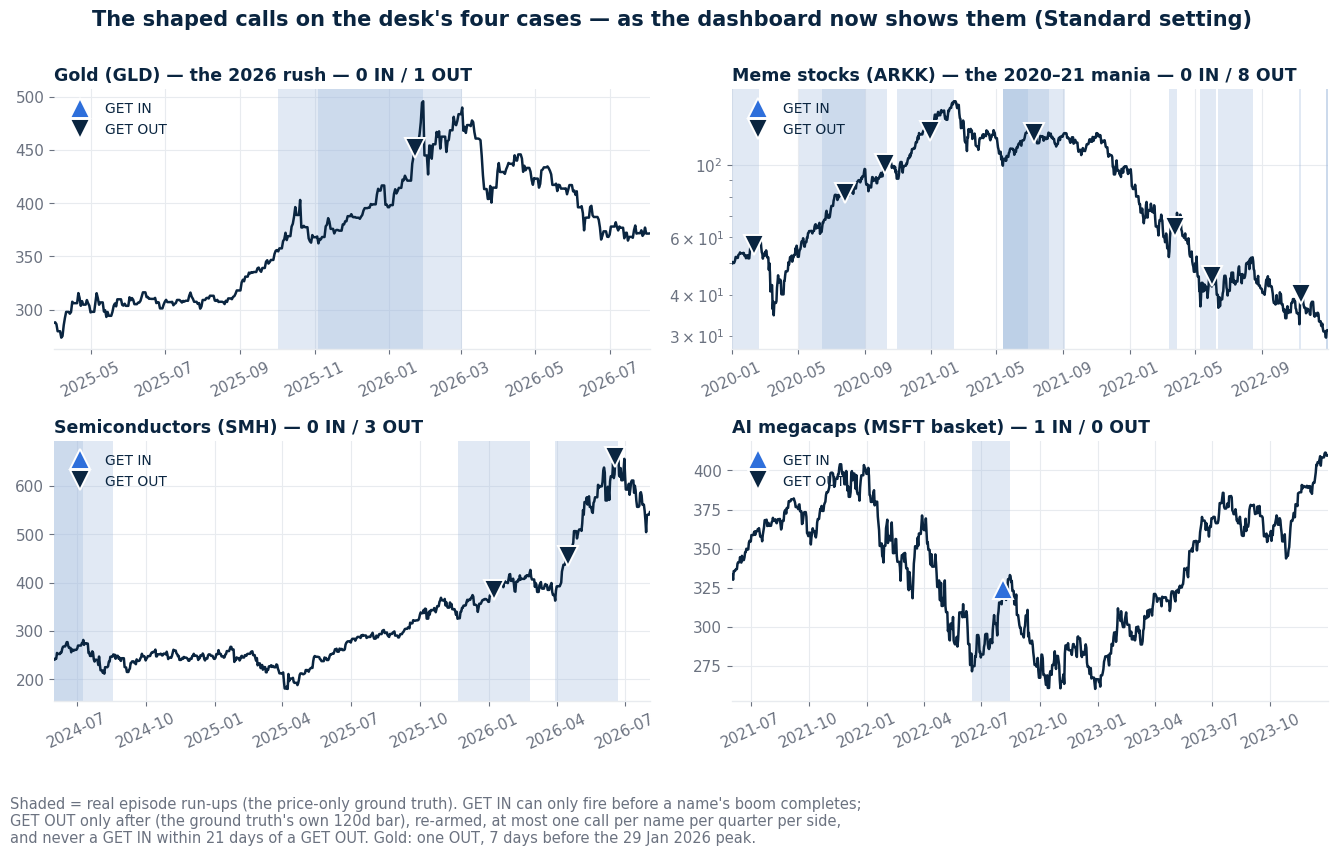

In [19]:
# S6d — the desk's four named cases, exactly as the dashboard shows them
# (the SHIPPED store's replay - the frozen final cut, shaped)
_desk_ds = pd.read_parquet(ROOT / "data" / "processed" /
                           "euphoria_desk.parquet")
_desk_ds["date"] = pd.to_datetime(_desk_ds["date"])
CASES4 = [("Gold (GLD) — the 2026 rush", "gold_metals",
           "2025-04-01", None),
          ("Meme stocks (ARKK) — the 2020–21 mania", "meme_stocks",
           "2020-01-01", "2022-12-31"),
          ("Semiconductors (SMH)", "semiconductors", "2024-06-01", None),
          ("AI megacaps (MSFT basket)", "ai_megacap",
           "2021-06-01", "2023-12-31")]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 7.6))
for ax, (title4, name4, w40, w41) in zip(axes.flat, CASES4):
    px4 = pxmap[sym_by[name4]].dropna()
    px4 = px4.loc[w40:w41] if w41 else px4.loc[w40:]
    g4 = _desk_ds[_desk_ds["name"] == name4]
    ins4 = [x for x in g4.loc[g4["get_in"], "date"]
            if px4.index.min() <= x <= px4.index.max()]
    outs4 = [x for x in g4.loc[g4["get_out"], "date"]
             if px4.index.min() <= x <= px4.index.max()]
    ax.plot(px4.index, px4.values, color=NAVY, lw=1.8)
    if px4.max() / max(px4.min(), 1e-9) > 4:
        ax.set_yscale("log")
    for r in episodes[episodes.name == name4].itertuples():
        if r.peak >= px4.index.min() and r.trough <= px4.index.max():
            ax.axvspan(max(r.trough, px4.index.min()),
                       min(r.peak, px4.index.max()), color=SKY,
                       alpha=0.3, lw=0)
    ax.plot(ins4, [px4.asof(x) for x in ins4], "^", color=BLUE, ms=14,
            mec="white", mew=1.4, zorder=5, label="GET IN")
    ax.plot(outs4, [px4.asof(x) for x in outs4], "v", color=NAVY, ms=14,
            mec="white", mew=1.4, zorder=5, label="GET OUT")
    ax.set_xlim(px4.index.min(), px4.index.max())
    ax.set_title(f"{title4} — {len(ins4)} IN / {len(outs4)} OUT",
                 loc="left", fontsize=12.5)
    ax.legend(frameon=False, fontsize=10, loc="upper left")
    despine(ax)
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("The shaped calls on the desk's four cases — as the "
             "dashboard now shows them (Standard setting)",
             fontsize=15, fontweight="bold", y=1.0)
fig.text(0.01, -0.035,
         "Shaded = real episode run-ups (the price-only ground truth). GET IN can only fire before a name's boom completes;\n"
         "GET OUT only after (the ground truth's own 120d bar), re-armed, at most one call per name per quarter per side,\n"
         "and never a GET IN within 21 days of a GET OUT. Gold: one OUT, 7 days before the 29 Jan 2026 peak.",
         fontsize=10.5, color=GREY, va="top")
fig.tight_layout()
save(fig, "S6d_four_cases.png")
plt.show()

---
# Q7 — How do the pieces combine into a GET IN or a GET OUT?

The chain on one chart: the two members each rank every (name, day) in
the market; the ensemble is their **equal-weight average of rankings**
(no tuned mixing weight); a SHAPED crossing of the learned cut fires
the call — GET IN only before the boom completes, GET OUT only after,
one call per name per quarter per side. Shown for the two cases the
desk asks about first: gold and GME.

saved docs/figures/slides/S7a_how_a_call_is_made_gold.png


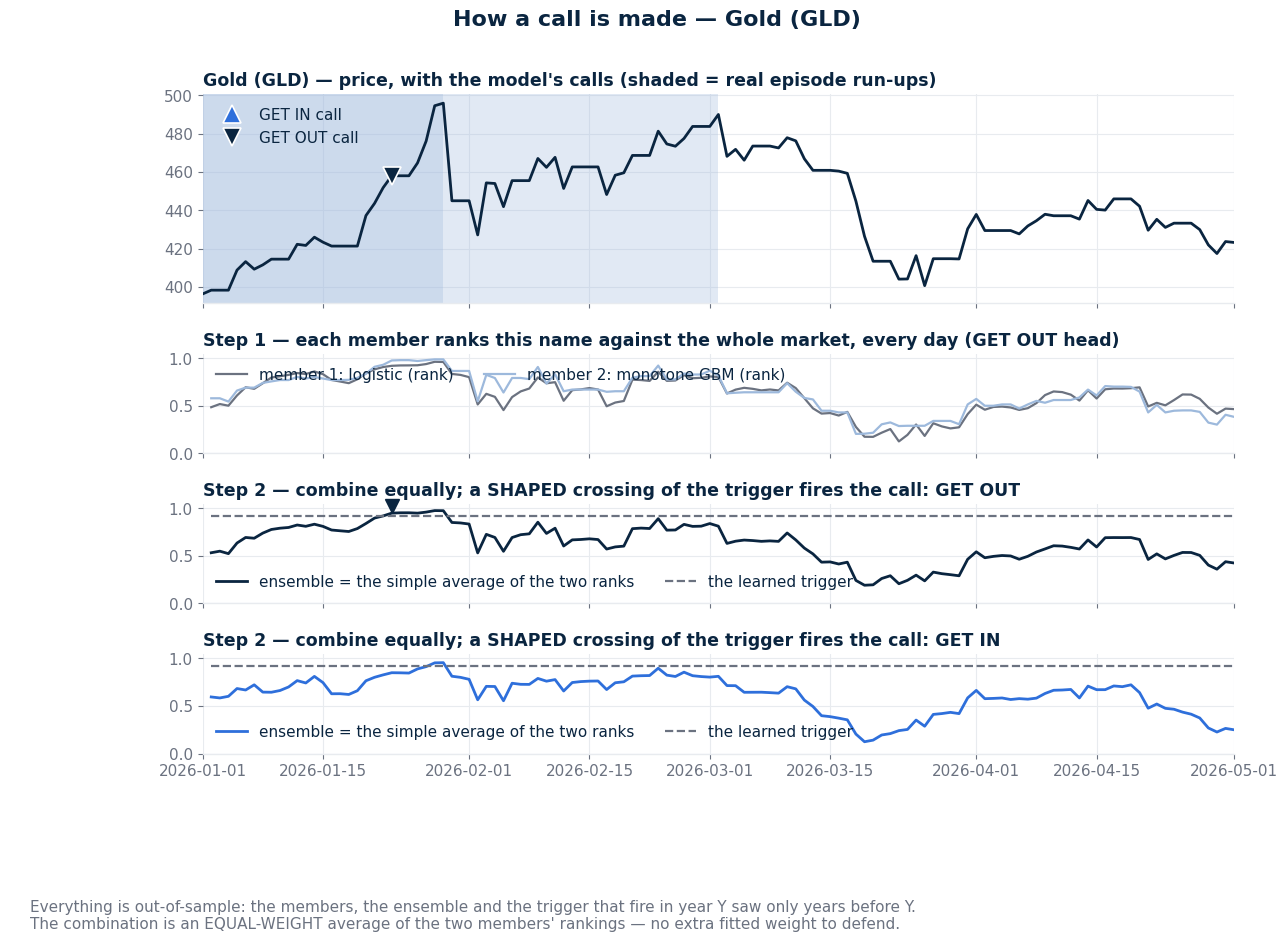

In [20]:
def slide_case(disp, name, sym, w0, w1, fname):
    d_out = WF[(WF["head"] == "GET OUT") & (WF["name"] == name)
               ].set_index("date").sort_index().loc[w0:w1]
    d_in = WF[(WF["head"] == "GET IN") & (WF["name"] == name)
              ].set_index("date").sort_index().loc[w0:w1]
    px = pxmap[sym].dropna().loc[w0:w1]
    a_out = [a for a in _adopted_alerts("GET OUT", name)
             if w0 <= str(a.date()) <= w1]
    a_in = [a for a in _adopted_alerts("GET IN", name)
            if w0 <= str(a.date()) <= w1]

    fig, axes = plt.subplots(4, 1, figsize=(12.8, 8.6), sharex=True,
                             height_ratios=[2.1, 1, 1, 1])
    ax = axes[0]
    ax.plot(px.index, px.values, color=NAVY, lw=2.0)
    if px.max() / max(px.min(), 1e-9) > 4:
        ax.set_yscale("log")
    _x0, _x1 = px.index.min(), px.index.max()
    for r in episodes[(episodes.name == name) & (episodes.peak >= w0)
                      & (episodes.peak <= w1)].itertuples():
        ax.axvspan(max(r.trough, _x0), min(r.peak, _x1), color=SKY,
                   alpha=0.3, lw=0)
    ax.set_xlim(_x0, _x1)
    ax.plot(a_in, [px.asof(a) for a in a_in], "^", color=BLUE, ms=13,
            mec="white", mew=1.2, label="GET IN call", zorder=5)
    ax.plot(a_out, [px.asof(a) for a in a_out], "v", color=NAVY, ms=13,
            mec="white", mew=1.2, label="GET OUT call", zorder=5)
    ax.set_title(f"{disp} — price, with the model's calls "
                 "(shaded = real episode run-ups)", fontsize=12.5,
                 loc="left")
    ax.legend(frameon=False, loc="upper left")
    despine(ax)

    ax = axes[1]
    ax.plot(d_out.index, d_out["logit_rank"], color=GREY, lw=1.6,
            label="member 1: logistic (rank)")
    ax.plot(d_out.index, d_out["gbm_rank"], color=SKY, lw=1.6,
            label="member 2: monotone GBM (rank)")
    ax.set_ylim(0, 1.05)
    ax.set_title("Step 1 — each member ranks this name against the whole "
                 "market, every day (GET OUT head)", fontsize=12.5,
                 loc="left")
    ax.legend(frameon=False, loc="upper left", ncols=2)
    despine(ax)

    for ax, d, head, c, al in ((axes[2], d_out, "GET OUT", NAVY, a_out),
                               (axes[3], d_in, "GET IN", BLUE, a_in)):
        ax.plot(d.index, d["score"], color=c, lw=2.0,
                label="ensemble = the simple average of the two ranks")
        thr_line = d["test_year"].map(lambda y: THR[head].get(int(y)))
        ax.plot(d.index, thr_line, color=GREY, lw=1.6, ls="--",
                label="the learned trigger")
        ax.plot(al, [1.02] * len(al), "v" if head == "GET OUT" else "^",
                color=c, ms=10, clip_on=False)
        ax.set_ylim(0, 1.05)
        ax.set_title(f"Step 2 — combine equally; a SHAPED crossing of "
                     f"the trigger fires the call: {head}",
                     fontsize=12.5, loc="left")
        ax.legend(frameon=False, loc="lower left", ncols=2)
        despine(ax)
    fig.suptitle(f"How a call is made — {disp}", fontsize=16,
                 fontweight="bold", y=1.005)
    fig.text(0.01, -0.03,
             "Everything is out-of-sample: the members, the ensemble and the trigger that fire in year Y saw only years before Y.\n"
             "The combination is an EQUAL-WEIGHT average of the two members' rankings — no extra fitted weight to defend.",
             fontsize=11, color=GREY, va="top")
    fig.tight_layout()
    save(fig, fname)
    plt.show()


# gold only enters the model's candidate frame in 2026 (the theme is
# new) - window the case to where the scores exist, so every panel fills
slide_case("Gold (GLD)", "gold_metals", "GLD", "2026-01-01", "2026-05-01",
           "S7a_how_a_call_is_made_gold.png")

saved docs/figures/slides/S7b_how_a_call_is_made_gme.png


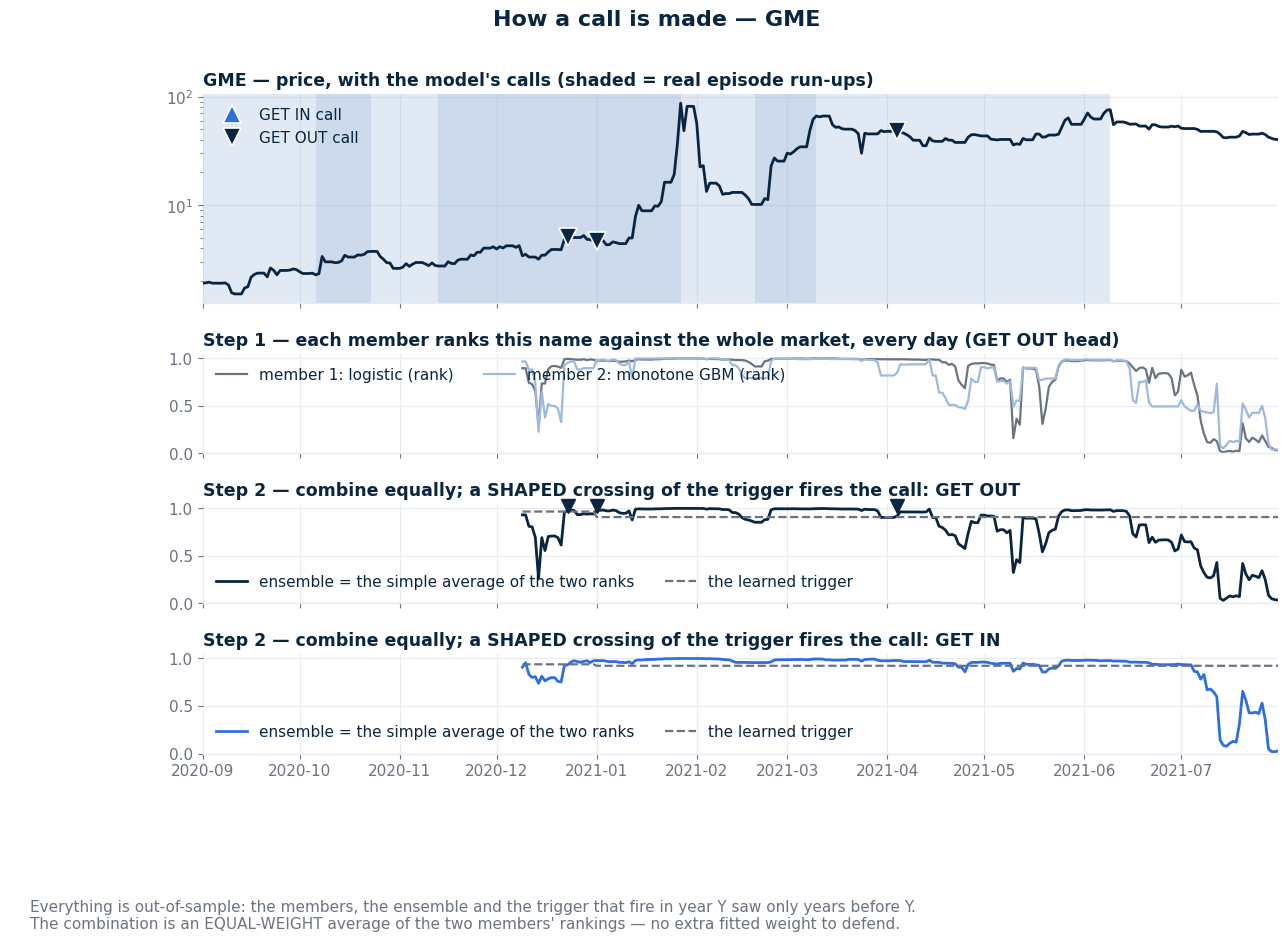

In [21]:
slide_case("GME", "GME", "GME", "2020-09-01", "2021-07-31",
           "S7b_how_a_call_is_made_gme.png")

---
# Q8 — How well does it perform, and is it better than what we ran
before?

The comparison rules first, so the answer cannot be an artifact of
framing: same frozen episode truth, same walk-forward machinery, each
system on its own candidacy (which is why score quality is compared on
**AP lift**, not raw AP). "The model" below is the SHIPPED
configuration — the ensemble with the SHAPED alerts of §6.5
(phase-gated, re-armed, quarterly-spaced, separated), Standard cut.

In [22]:
# the shipped configuration's walk-forward record (the ADOPTED shaped
# alerts frozen in alert_shape_sweep.json)
SHIP = {h: SHAPE["adopted"]["standard"][h] for h in ("GET OUT", "GET IN")}
STRICT = {h: SHAPE["adopted"]["strict"][h] for h in ("GET OUT", "GET IN")}
RULES = {"GET OUT": RES["get_out"]["rules"], "GET IN": RES["get_in"]["rules"]}

_hh_rows = []
for _head in ("GET OUT", "GET IN"):
    for _sys, _r in (("previous rules", RULES[_head]),
                     ("MODEL — Standard", SHIP[_head]),
                     ("MODEL — Strict", STRICT[_head])):
        _hh_rows.append({
            "head": _head, "system": _sys,
            "caught": f"{_r['captured']}/{_r['detectable']} "
                      f"({_r['capture_rate']:.0%})",
            "FA/instr-yr": round(_r["fa_per_iy"], 2),
            "precision": round(_r["precision"], 2),
        })
display(pd.DataFrame(_hh_rows).set_index(["head", "system"]))
for _head, _hk in (("GET OUT", "get_out"), ("GET IN", "get_in")):
    _ru, _mlr = RULES[_head], SHIP[_head]
    _lift = RES[_hk]["ens"]["ap"] / RES[_hk]["ens"]["ap_baseline"]
    _rl = _ru["ap"] / _ru["ap_baseline"]
    print(f"{_head}: {_mlr['capture_rate']/_ru['capture_rate']:.1f}x the "
          f"episodes caught ({_mlr['capture_rate']:.0%} vs "
          f"{_ru['capture_rate']:.0%}), score quality {_lift:.1f}x vs "
          f"{_rl:.1f}x better-than-guessing (rules: barely above chance)")

caught  FA/instr-yr  precision
head    system                                                
GET OUT previous rules    22/188 (12%)         0.09       0.59
        MODEL — Standard  63/218 (29%)         0.12       0.53
        MODEL — Strict    50/218 (23%)         0.09       0.54
GET IN  previous rules     18/198 (9%)         0.18       0.17
        MODEL — Standard  21/198 (11%)         0.10       0.30
        MODEL — Strict     10/198 (5%)         0.04       0.37

GET OUT: 2.5x the episodes caught (29% vs 12%), score quality 2.5x vs 1.1x better-than-guessing (rules: barely above chance)
GET IN: 1.2x the episodes caught (11% vs 9%), score quality 2.5x vs 1.2x better-than-guessing (rules: barely above chance)


saved docs/figures/slides/S8a_the_record.png


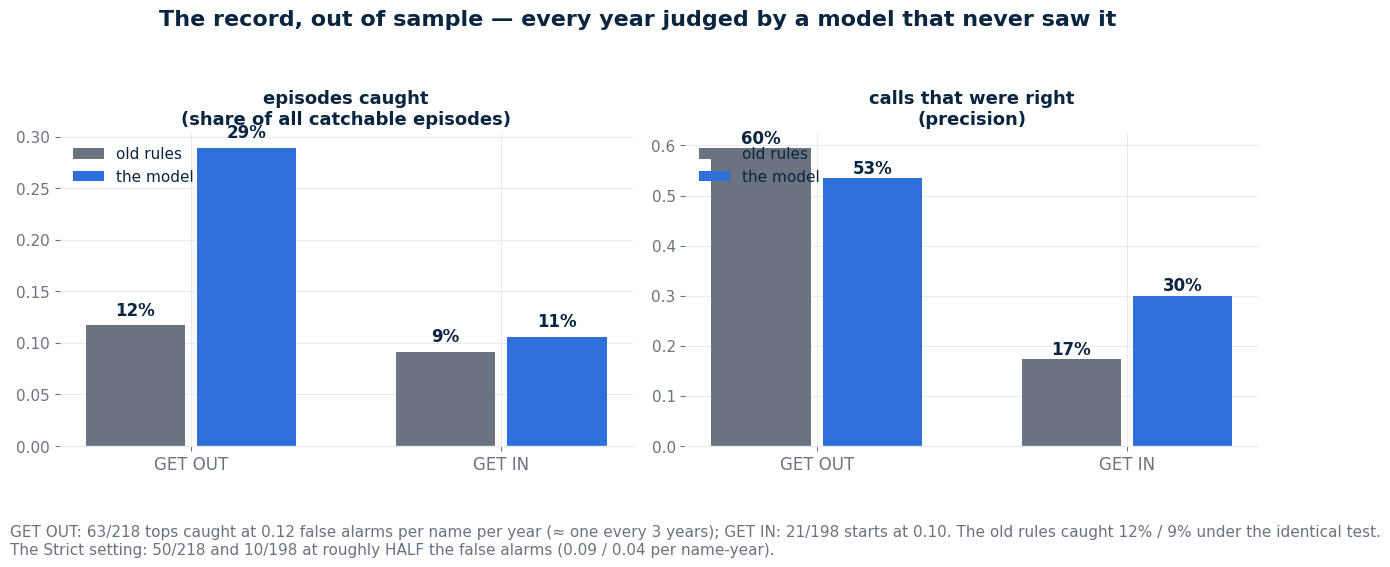

In [23]:
# S8a — the operational record vs the old system
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))
heads = ["GET OUT", "GET IN"]
for ax, metric, ttl, fmt in (
        (axes[0], "capture_rate", "episodes caught\n(share of all "
         "catchable episodes)", "{:.0%}"),
        (axes[1], "precision", "calls that were right\n(precision)",
         "{:.0%}")):
    xs = np.arange(2)
    rv = [RULES[h][metric] for h in heads]
    mv = [SHIP[h][metric] for h in heads]
    b1 = ax.bar(xs - 0.18, rv, 0.32, color=GREY, label="old rules")
    b2 = ax.bar(xs + 0.18, mv, 0.32, color=BLUE, label="the model")
    for bars in (b1, b2):
        for b in bars:
            ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                    fmt.format(b.get_height()), ha="center", fontsize=12,
                    fontweight="bold", color=NAVY)
    ax.set_xticks(xs, heads, fontsize=12)
    ax.set_title(ttl, fontsize=13)
    ax.legend(frameon=False, loc="upper left")
    despine(ax)
fig.suptitle("The record, out of sample — every year judged by a model "
             "that never saw it", fontsize=16, fontweight="bold", y=1.05)
_o, _i = SHIP["GET OUT"], SHIP["GET IN"]
fig.text(0.01, -0.07,
         f"GET OUT: {_o['captured']}/{_o['detectable']} tops caught at {_o['fa_per_iy']:.2f} false alarms per name per year "
         f"(≈ one every 3 years); GET IN: {_i['captured']}/{_i['detectable']} starts at {_i['fa_per_iy']:.2f}. "
         "The old rules caught 12% / 9% under the identical test.\n"
         f"The Strict setting: {STRICT['GET OUT']['captured']}/{STRICT['GET OUT']['detectable']} and "
         f"{STRICT['GET IN']['captured']}/{STRICT['GET IN']['detectable']} at roughly HALF the false alarms "
         f"({STRICT['GET OUT']['fa_per_iy']:.2f} / {STRICT['GET IN']['fa_per_iy']:.2f} per name-year).",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S8a_the_record.png")
plt.show()

saved docs/figures/slides/S8b_the_tape_agrees.png


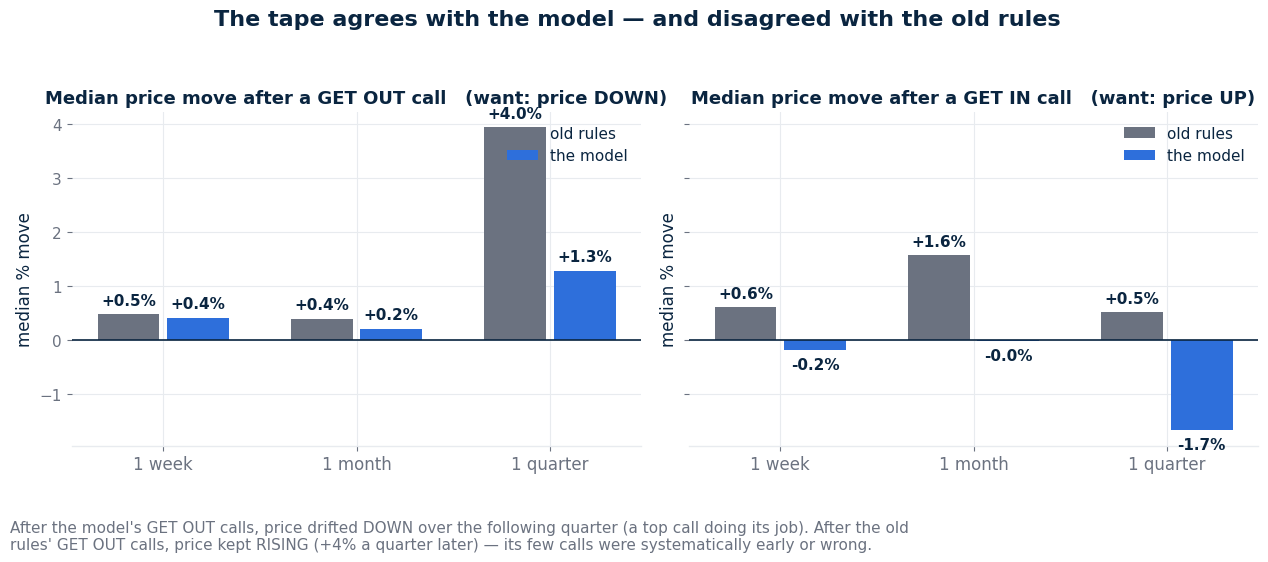

In [24]:
# S8b — the tape's own verdict: what price did after each call
# (the shipped alert sets and their forward returns, from the frozen
# adopted record)
_ship_alerts = {h: {n: list(_adopted_alerts(h, n))
                    for n in WF["name"].unique()}
                for h in ("GET OUT", "GET IN")}
FWD_SHIP = SHAPE["adopted"]["standard"]["forward_returns"]

H = [("fwd_5d", "1 week"), ("fwd_21d", "1 month"), ("fwd_84d", "1 quarter")]
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), sharey=True)
for ax, head, ttl, want in ((axes[0], "GET OUT",
                             "after a GET OUT call", "want: price DOWN"),
                            (axes[1], "GET IN",
                             "after a GET IN call", "want: price UP")):
    xs = np.arange(len(H))
    rv = [RULES[head]["forward_returns"][k]["median_pct"] for k, _ in H]
    mv = [FWD_SHIP[head][k]["median_pct"] for k, _ in H]
    b1 = ax.bar(xs - 0.18, rv, 0.32, color=GREY, label="old rules")
    b2 = ax.bar(xs + 0.18, mv, 0.32, color=BLUE, label="the model")
    ax.axhline(0, color=NAVY, lw=1.2)
    for bars in (b1, b2):
        for b in bars:
            v = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2,
                    v + (0.12 if v >= 0 else -0.12),
                    f"{v:+.1f}%", ha="center",
                    va="bottom" if v >= 0 else "top", fontsize=11,
                    fontweight="bold", color=NAVY)
    ax.set_xticks(xs, [t for _, t in H], fontsize=12)
    ax.set_title(f"Median price move {ttl}   ({want})", fontsize=13)
    ax.set_ylabel("median % move")
    ax.legend(frameon=False, loc="upper right")
    despine(ax)
fig.suptitle("The tape agrees with the model — and disagreed with the "
             "old rules", fontsize=16, fontweight="bold", y=1.05)
fig.text(0.01, -0.06,
         "After the model's GET OUT calls, price drifted DOWN over the following quarter (a top call doing its job). After the old\n"
         "rules' GET OUT calls, price kept RISING (+4% a quarter later) — its few calls were systematically early or wrong.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S8b_the_tape_agrees.png")
plt.show()

saved docs/figures/slides/S8c_event_study.png


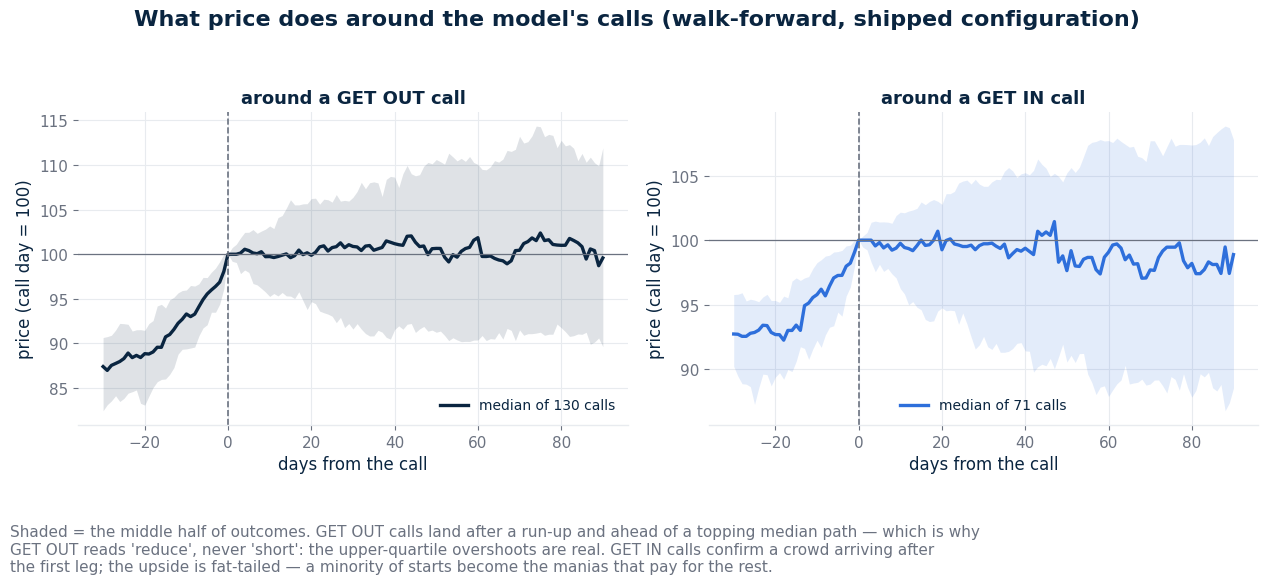

In [25]:
# S8c — the event study: the median price path around the shipped calls
HORIZON_PRE, HORIZON_POST = 30, 90


def paths_around(dates_by_name):
    paths = []
    for name, dts in dates_by_name.items():
        px = pxmap.get(sym_by.get(name))
        if px is None:
            continue
        px = px.dropna()
        for d in dts:
            w = px.loc[d - pd.Timedelta(days=HORIZON_PRE):
                       d + pd.Timedelta(days=HORIZON_POST)]
            p0 = px.asof(d)
            if pd.isna(p0) or p0 == 0 or len(w) < 30:
                continue
            rel = (w / p0) * 100
            rel.index = (rel.index - d).days
            paths.append(rel)
    if not paths:
        return None
    grid = pd.DataFrame(paths).T.sort_index()
    return grid.loc[-HORIZON_PRE:HORIZON_POST]


fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6), sharex=True)
for ax, head, title, c in ((axes[0], "GET OUT",
                            "around a GET OUT call", NAVY),
                           (axes[1], "GET IN",
                            "around a GET IN call", BLUE)):
    grid = paths_around(_ship_alerts[head])
    med = grid.median(axis=1)
    q25, q75 = grid.quantile(0.25, axis=1), grid.quantile(0.75, axis=1)
    ax.fill_between(med.index, q25, q75, color=c, alpha=0.13, lw=0)
    ax.plot(med.index, med.values, color=c, lw=2.4,
            label=f"median of {grid.shape[1]} calls")
    ax.axvline(0, color=GREY, lw=1.2, ls="--")
    ax.axhline(100, color=GREY, lw=0.9)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("days from the call")
    ax.set_ylabel("price (call day = 100)")
    ax.legend(frameon=False, fontsize=10)
    despine(ax)
fig.suptitle("What price does around the model's calls (walk-forward, "
             "shipped configuration)", fontsize=16, fontweight="bold",
             y=1.05)
fig.text(0.01, -0.07,
         "Shaded = the middle half of outcomes. GET OUT calls land after a run-up and ahead of a topping median path — which is why\n"
         "GET OUT reads 'reduce', never 'short': the upper-quartile overshoots are real. GET IN calls confirm a crowd arriving after\n"
         "the first leg; the upside is fat-tailed — a minority of starts become the manias that pay for the rest.",
         fontsize=11, color=GREY, va="top")
fig.tight_layout()
save(fig, "S8c_event_study.png")
plt.show()

---
# The decision log (what we tested → what we decided → why)

| # | We tested | We decided | Because |
|---|---|---|---|
| 1 | Was the data broken or the estimator? (per-source coverage audit, §P) | Fix the ESTIMATOR: ratio-of-sums + stratification + shrinkage; no imputation | 308 fake zero-days traced to pull cadence + source mix; inventing posts would poison the counts |
| 2 | Ground-truth bars at 25/50, 20/40, 15/30 — full walk-forward per level (§1) | **20/40 boom, 12/25 bust** | Doubles episodes, keeps gold/meme/semis, accuracy improves; 15/30 makes "euphoria" = any correction |
| 3 | 5 model families × 2 feature sets, walk-forward, pre-stated rule (§5) | **logit + monotone-GBM rank ensemble**, crowd+price bank | Highest combined AP lift (2.45× / 2.55×); best hit-rate-to-FA trade of any learner |
| 4 | Keep the gate stack or hand gates to the model? | Gates become FEATURES; 3 numbers survive (coverage floor, cooldown, learned cut) | Same information, no per-constant defence needed; capture 12%→~41% and 9%→~55% |
| 5 | MLP as the ceiling check | NOT adopted — reported as a null | ~500 positives cannot fund a deeper model; it never beat the ensemble |
| 6 | Crowd-only versions of every learner | Kept as the parallel record, not shipped for the desk | The desk signals are licensed to use price; the "crowd alone" claim keeps its own honest (weaker) record |
| 7 | START-on-top-of-END coherence | Kept as a display-layer rule under every model, in BOTH signal settings | Desk stated three times this is the error that destroys PM trust; one sentence to explain |
| 8 | Alert shape, two rounds: smoothing / stricter cut / crossing (8 configs), then phase gates × re-arm depth × spacing (24 configs) | **Shaped calls**: GET OUT only post-boom (120d G2 bar, re-arm at cut), GET IN only pre-boom (re-arm at train-median), 63d spacing, 21d IN/OUT separation both directions; smoothing REJECTED | Desk order ("one clear call per boom; never IN and OUT together"); calls-per-boom 1.6→1.2, GET OUT precision 0.36→0.53, adjacency zero by construction; evidence `conditioning_sweep.json` + `alert_shape_sweep.json` |

# Limitations, said plainly, then the PM line

- **The frozen cuts are young.** Selected by train-year F-measures
  under a ground truth adopted the same week; their real out-of-sample
  test is the forward signal snapshots, which accumulate from now.
- **2026 dominates the multi-source era.** StockTwits/X exist in the
  live archive only from 2026; earlier years are effectively
  Reddit-only, and the stratified estimator handles but cannot erase
  that asymmetry.
- **Median GET OUT forward moves are flat-to-negative; means are
  positive.** Manias overshoot: a top-caller's misses keep rallying.
  That is why the desk reads GET OUT as "reduce", never "short".
- **Parsimony was bought with capture** (DESK DECISION 2026-08-09):
  the un-shaped model caught 41%/55% of episodes; the shaped calls
  catch 29%/11% — the desk chose clean, phase-correct, one-per-boom
  calls over raw coverage, and the un-shaped record remains frozen in
  the tournament table for comparison.
- **Late GET INs are now suppressed by design** — a start may only be
  called before the boom completes, so a crowd that arrives late
  (gold 2026) yields no GET IN at all; the GET OUT still protects the
  exit.

**The PM line:** *the crowd, plus the tape, read by a two-model
ensemble that only ever trains on the past, calls roughly three in
ten episode tops a median of six days before the peak — two and a
half times what the hand rules caught, at better than one false alarm
per name per eight years — and flags fresh crowd arrivals only while
the boom is still young; at most one call per name per quarter per
side, never a GET IN within three weeks of a GET OUT, a Strict
setting that thins it further, and a comparison table for every
alternative we declined.*

## The manifest — every number the slides quote, frozen in one place

In [26]:
manifest = {
    "figures": SAVED,
    "palette": {"navy": NAVY, "blue": BLUE, "sky": SKY, "grey": GREY},
    "winner": RES["winner"],
    "conditioning": desk_rep.get("conditioning"),
    "headline": {
        h: {"rules": {k: RULES[h].get(k) for k in
                      ("captured", "detectable", "capture_rate",
                       "precision", "fa_per_iy", "forward_returns")},
            "shipped_standard": SHIP[h],
            "shipped_strict": STRICT[h],
            "forward_returns_shipped": FWD_SHIP[h]}
        for h in ("GET OUT", "GET IN")},
    "score_quality": {hk: {"ap": RES[hk]["ens"]["ap"],
                           "ap_baseline": RES[hk]["ens"]["ap_baseline"],
                           "auroc": RES[hk]["ens"]["auroc"]}
                      for hk in ("get_out", "get_in")},
    "thresholds": {h: THR[h] for h in ("GET OUT", "GET IN")},
    "strict_thresholds_final": {
        "GET IN": desk_rep["get_in"].get("strict_threshold"),
        "GET OUT": desk_rep["get_out"].get("strict_threshold")},
    "ablation": {h: abl[h][1].to_dict(orient="records") for h in abl},
    "ablation_note": "final fold (fit < newest year, tested on it); "
                     "delta = AP(all 11) - AP(without the feature)",
    "alert_shape": SHAPE["adopted"]["config"],
}
with open(RESEARCH_DIR / "nb07_slide_pack.json", "w") as f:
    json.dump(manifest, f, indent=1, default=str)
print(f"saved nb07_slide_pack.json | {len(SAVED)} slide figures:")
for s in SAVED:
    print("  ", s)

saved nb07_slide_pack.json | 20 slide figures:
   S0a_source_regime.png
   S0b_estimator_fix.png
   S1a_what_we_hunt.png
   S1b_why_these_bars.png
   S1c_episode_anatomy.png
   S2a_three_streams.png
   S2b_the_11_measurements.png
   S3_the_menu.png
   S4a_feature_auroc.png
   S4b_ablation.png
   S5_why_this_model.png
   S6a_score_distributions.png
   S6b_spearman_and_cuts.png
   S6c_flip_flop_fix.png
   S6d_four_cases.png
   S7a_how_a_call_is_made_gold.png
   S7b_how_a_call_is_made_gme.png
   S8a_the_record.png
   S8b_the_tape_agrees.png
   S8c_event_study.png
